In [3]:
import pandas as pd
import gzip
import shutil

import gdown
import numpy as np



from rich.console import Console
from rich.table import Table

from sklearn.decomposition import PCA
import plotly.graph_objs as go

# Práctica 5 - Preprocesamiento de datos

>[Práctica 5 - Preprocesamiento de datos](#scrollTo=7ufh4aLFD1pb)

>>[Tratamiento de valores faltantes](#scrollTo=JQNNKS3ZEqZl)

>>>[Tipos de valores faltantes](#scrollTo=SXKKjF-NO2J9)

>>>[Estrategias](#scrollTo=5tFosWJaPVSO)

>>>[Imputación de valores faltantes:](#scrollTo=wv3EVnohPiD6)

>>>>[a. Media/Mediana/Moda](#scrollTo=Z3HoNKh3w9m-)

>>>>[b. Hot deck](#scrollTo=cosUzgiTx2ZM)

>>>>[c. Regresión](#scrollTo=ZyynPDJ2I3DE)

>>>>[d. MICE (Multiple Imputation by Chained Equations)](#scrollTo=SBuuswTgT7hF)

>>>>[e. Completar con datos de fuentes externas](#scrollTo=IhYF8XC9aF51)

>>>>[f. Interpolación en series temporales](#scrollTo=XnV1N6jXetuq)

>>[Detección de valores atípicos (outliers)](#scrollTo=Lsg0kMLvmsRW)

>>>[Análisis univariado](#scrollTo=1AH0-i-kR6RV)

>>>>[1. Boxplots](#scrollTo=nOrQyFEHlUm_)

>>>>[2. Z-score](#scrollTo=HRMhpm_flh6j)

>>>>[3. Z-score modificado](#scrollTo=GPkLsq9alqQb)

>>>>[Inconveniente de los métodos univariados](#scrollTo=E9jzegeNkGjK)

>>>[Análisis multivariado](#scrollTo=IkBOC8S_lz5e)

>>>>[1. Distancia de Mahalanobis](#scrollTo=d98XsNN2XrNW)

>>>>[2. Local Outlier Factor (LOF)](#scrollTo=kET8Xl1xX5P9)

>>>>[3. Isolation forest](#scrollTo=YU4-_kIoYY1e)

>>[Ingeniería de atributos](#scrollTo=ZMi-7Yc9Eu6C)

>>>[Normalización de variables](#scrollTo=y6Nz8q-QE2uQ)

>>>[Binning](#scrollTo=j0f_5XF2eCMk)

>>>[Variables dummies](#scrollTo=B7y6AhJRajFZ)

>>>[Creación de nuevas variables](#scrollTo=cI-Ag89dw64j)

>>>[Análisis de componentes principales (PCA)](#scrollTo=KP9vdicUE_Sd)

>>>>[Concepto y propósito:](#scrollTo=ugnB3ER1g44o)

>>>>[Desde el punto de vista geométrico:](#scrollTo=P3ZPwTL5H_yp)

>>>>[Desde el punto de vista matemático:](#scrollTo=ft7kgzBaHSBb)

>>>>[Ejemplo con 3 variables:](#scrollTo=XswgPOjyhGeN)

>>>>[Reducción de dimensionalidad: ¿con cuántas componentes me quedo?](#scrollTo=SjCWg0sGJuJ6)

>>[Ejercicio práctico: dataset de propiedades](#scrollTo=fDeDiqTDFXn8)

>>>[Descarga del dataset](#scrollTo=BL0LbuWO3Sew)

>>>[Exploración del dataset](#scrollTo=UeZyiI173WT3)

>>>[Objetivo](#scrollTo=nz9Kif5V3OgA)

>>>[Eliminación de features redundantes](#scrollTo=5p-LATr_BLLx)

>>>[Tratamiento de variables temporales](#scrollTo=ctXVKv1zDLYS)

>>>[Tratamiento de variables georreferenciadas](#scrollTo=Pi2DclVWL-bF)

>>>[Checkpoint](#scrollTo=3IiM0nTUt0Eh)

>>>[Tratamiento de variables de texto](#scrollTo=S4pexWd3RDdZ)

>>>>[Sample Regexs](#scrollTo=S4pexWd3RDdZ)

>>>>[Ejemplos](#scrollTo=jJOJ0p7yknB2)

>>>>[Sample de las variables de texto](#scrollTo=Bn6pxrKuTDB5)

>>>>[Definición de expresiones regulares para poblar el dataset](#scrollTo=kk7t8noDTITF)

>>>>[Ambientes](#scrollTo=-Wmu63Y4RJsj)

>>>>[Superficie](#scrollTo=LJ5CXmc33xXq)

>>[Checkpoint #2](#scrollTo=9OhnjRa2Bo2N)

>>>[Tuning final del dataset](#scrollTo=toOWxXm76gRy)

>>>[Tratamiento de outliers](#scrollTo=gIPQ5m05JPZg)

>>[Checkpoint #3](#scrollTo=DKiKS1GyQF7h)

>>>[MICE](#scrollTo=5Lmovt_QFiyF)

>>>[Normalización de variables](#scrollTo=w5SKe5sZRQ9r)

>>>[¿Para qué sirvió?](#scrollTo=jZHLafniVFMk)

>>>>[Modelo sobre dataset procesado](#scrollTo=C8Mw6NhGVS9T)

>>>>[Modelo sobre dataset crudo](#scrollTo=jtCBn7pqYAej)

>>[Bibliografía](#scrollTo=LmlxWP8zeeV3)



## Tratamiento de valores faltantes
En cualquier proyecto de ciencia de datos es común encontrarse con valores faltantes dentro de un conjunto de datos. Estos pueden surgir por distintos motivos: errores en la recolección, limitaciones en los sistemas de registro o simplemente porque cierta información no estaba disponible en el momento. Identificarlos y tratarlos correctamente es un paso clave en el preprocesamiento, ya que los valores faltantes pueden afectar la calidad del análisis, distorsionar estadísticas y perjudicar el rendimiento de los modelos de machine learning

### Tipos de valores faltantes

**MCAR (Missing Completely At Random):**
* La falta de datos es completamente aleatoria y no está relacionada con el conjunto de datos.
* Ejemplos:
  * Datos faltantes de temperatura debido a que el sensor se quedó sin batería.
  * Registros faltantes por falla del disco donde se encontraban almacenados los datos.
  * Llamados a clientes recientes para una encuesta de satisfacción, algunos no atienden por razones aleatorias.


**MNAR (Missing Not At Random):**
* La falta de datos no es aleatoria y está relacionada con la misma variable.
* Ejemplos:
  * En encuestas salariales, quienes ganan más pueden optar por no responder.
  * Puntuación de un producto luego de una compra: quienes no tuvieron problemas suelen no calificar (no ocurre lo mismo con quienes tuvieron incovenientes).
  * En estaciones meteorológicas, los sensores de temperatura pueden no registrar valores extremadamente bajos porque alcanzan su límite de medición y dejan de funcionar.


**MAR (Missing At Random):**
* La falta de datos no está relacionada con la variable con datos faltantes pero puede explicarse con otras variables del dataset.
* Ejemplos:
  * Base de datos unficada de pacientes con una misma patología, donde figuran datos del paciente, resultados de sus estudios y además se indica el centro de salud donde se atiende. Determinado hospital tiene averiado un equipo para realizar cierto estudio.
  * Datos de ventas: calificación de un producto solo disponible en ventas online, valor faltante en las ventas presenciales en el local.





### Estrategias
* Elminar registros o variables:

Es viable cuando la cantidad de datos es suficiente. (No se recomienda en casos que no sean MCAR).

* Imputar datos faltantes:

Existen distintas formas de hacerlo. En estos casos es **muy importante** siempre conservar los datos orginales.

### Imputación de valores faltantes:
**a.** Media/mediana/moda

**b.** Hot deck

**c.** Regresión

**d.** MICE

**e.** Complementar con otro dataset

**f.** Interpolación en series temporales

#### **a. Media/Mediana/Moda**

In [ ]:
!gdown 1qZ4MHfPcIUp62GySms58KT9UfImibeg0

Downloading...
From: https://drive.google.com/uc?id=1qZ4MHfPcIUp62GySms58KT9UfImibeg0
To: /content/IMCinfantil_con_faltantes.xlsx
100% 17.0k/17.0k [00:00<00:00, 36.0MB/s]


In [ ]:
datos = pd.read_excel('IMCinfantil_con_faltantes.xlsx', index_col=0)
datos

,EDAD,SEXO,PESO,TALLA,CC,CatPeso
PACIENTE,,,,,,
1,7,M,24.4,1.2,54,N
2,7,M,23.6,1.2,52,N
3,8,M,47.0,1.4,76,OB
4,7,F,NaN,1.2,63,N
5,7,M,23.9,1.2,56,N
...,...,...,...,...,...,...
146,11,M,NaN,1.5,84,SO
147,8,M,26.5,1.2,57,NaN
148,6,F,21.5,1.1,57,N


In [ ]:
datos.isna()

,EDAD,SEXO,PESO,TALLA,CC,CatPeso
PACIENTE,,,,,,
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,True,False,False,False
5,False,False,False,False,False,False
...,...,...,...,...,...,...
146,False,False,True,False,False,False
147,False,False,False,False,False,True
148,False,False,False,False,False,False


In [ ]:
datos.isna().sum()

,0
EDAD,0
SEXO,15
PESO,20
TALLA,0
CC,0
CatPeso,15


In [ ]:
# SEXO
datos.SEXO.value_counts()

,count
SEXO,
F,69
M,66


In [ ]:
datos['SEXO'] = datos['SEXO'].fillna('F')
datos.SEXO.value_counts()

,count
SEXO,
F,84
M,66


In [ ]:
# PESO
media_PESO = datos.PESO.mean()
desvio_PESO = datos.PESO.std()
print(f'Valor medio de la variable peso: {media_PESO:.2f}')
print(f'Desvío estándar de la variable peso: {desvio_PESO:.2f}')

datos['PESO'] = datos['PESO'].fillna(media_PESO)

media_PESO = datos.PESO.mean()
desvio_PESO = datos.PESO.std()
print(f'Valor medio de la variable peso con valores imputados: {media_PESO:.2f}')
print(f'Desvío estándar de la variable peso con valores imputados: {desvio_PESO:.2f}')


Valor medio de la variable peso: 33.37
Desvío estándar de la variable peso: 11.27
Valor medio de la variable peso con valores imputados: 33.37
Desvío estándar de la variable peso con valores imputados: 10.49


In [ ]:
# CatPeso
distribucion_CatPeso = datos.CatPeso.value_counts(normalize=True).reindex(['D', 'N', 'SO', 'OB'])
distribucion_CatPeso

,proportion
CatPeso,
D,0.044444
N,0.614815
SO,0.162963
OB,0.177778


In [ ]:
datos['CatPeso'].fillna('N', inplace=True)

/tmp/ipython-input-940365932.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datos['CatPeso'].fillna('N', inplace=True)


In [ ]:
datos.isna().sum()

,0
EDAD,0
SEXO,0
PESO,0
TALLA,0
CC,0
CatPeso,0


#### **b. Hot deck**
Los valores para reemplazar los nulos se obtienen de registros ***similares*** dentro del mismo dataset.(Más adelante en la materia veremos cómo definir cuáles son los registros más similares).

* Hot deck aleatorio:

 El valor faltante se reemplaza por un valor observado de otro registro elegido de manera aleatoria dentro de un grupo de registros con características similares.

* Hot deck determinístico:

  El valor faltante se reemplaza por el valor del registro *más cercano*.

#### **c. Regresión**
Nuevamente es un tema que vamos a profundizar más adelante en la materia.

La idea es estimar los valores faltantes de un atributo en función de los valores de las demás variables.

Vamos a plantear un ejemplo simplificado, donde para completar los valores faltantes de peso, vamos a hacer un ajuste por cuadrados mínimos a partir de las otras tres variables numéricas: edad, talla y CC.

En este caso el objetivo sería encontrar los coeficientes de la siguiente fórmula de ajuste:
$PESO = a \cdot EDAD + b \cdot TALLA + c \cdot CC+ d $

Esa expresión nos va a permitir estimar los valores faltantes de la variable PESO.


In [ ]:
datos = pd.read_excel('IMCinfantil_con_faltantes.xlsx', index_col=0)

In [ ]:
# Eliminar filas con NaN en las variables que nos interesan
datos_numericos = datos[['EDAD', 'PESO', 'TALLA', 'CC']].dropna()

# Dividir los datos en características (X) y variable objetivo (y)
X = datos_numericos.drop(['PESO'], axis=1)
y = datos_numericos['PESO']

# Agregar columna de unos a X para tener en cuenta el intercept
# (coeficiente "d" de la fórmula planteada).
X['auxiliar'] = 1

In [ ]:
import scipy

ajuste = scipy.linalg.lstsq(X, y) #ajuste por cuadrados mínimos (lstsq: "least squares")
coeficientes_ajuste = ajuste[0]
a = coeficientes_ajuste[0]
b = coeficientes_ajuste[1]
c = coeficientes_ajuste[2]
d = coeficientes_ajuste[3]
print(f'a: {a:.2f}, b: {b:.2f}, c: {c:.2f}, d: {d:.2f}')

a: -0.41, b: 43.23, c: 0.63, d: -61.55


In [ ]:
datos_peso_faltante = datos[datos.PESO.isna()]
datos_peso_faltante

,EDAD,SEXO,PESO,TALLA,CC,CatPeso
PACIENTE,,,,,,
4,7,F,NaN,1.2,63,N
6,10,M,NaN,1.4,78,SO
7,7,M,NaN,1.3,69,OB
20,6,F,NaN,1.2,52,N
25,7,M,NaN,1.2,56,N
28,7,F,NaN,1.3,57,N
29,9,F,NaN,1.3,57,NaN
33,8,F,NaN,1.3,74,SO
53,9,M,NaN,1.4,82,OB


In [ ]:
for index, row in datos_peso_faltante.iterrows():
  edad = row.EDAD
  talla = row.TALLA
  cc = row.CC
  peso_estimado = a*edad + b*talla + c*cc + d
  datos.loc[index, 'PESO'] = peso_estimado


In [ ]:
datos.sample(5)

,EDAD,SEXO,PESO,TALLA,CC,CatPeso
PACIENTE,,,,,,
14,9,M,58.5,1.5,88,OB
70,9,M,33.5,1.4,67,N
15,9,F,23.7,1.3,58,D
120,8,M,34.2,1.3,79,OB
78,10,M,46.3,1.5,72,SO


#### **d. MICE (Multiple Imputation by Chained Equations)**

Trabaja sobre el supuesto de que el mecanismo de valores faltantes es MAR.

Imputa los valores faltantes utilizando modelos predictivos de forma iterativa. En cada iteración, cada variable del dataset es completada usando las variables restantes. Se itera hasta que converja.

Pasos:


1.   Los valores faltantes están indicados en rojo.
2.   Se realiza una primera imputación de los valores faltantes con valores aleatorios o utilizando alguno de los métodos vistos anteriormente. De esta forma el dataset queda completo.
3. Con algún modelo predictivo (de los que veremos en la segunda parte de la materia) se predicen los valores faltantes originales de A, a partir de los datos completos de B y C.
4. De la misma manera se realiza la predicción de B en función de A y C. Por último, se realiza la predicción de C en función de A y B.

Esos pasos corresponden a la primera iteración. En las iteraciones siguientes los valores inputados de cada variable son actualizados a partir de los nuevos datos. Este procedimiento continúa hasta que los valores lleguen a la convergencia (es decir, entre dos iteraciones seguidas los valores inputados no cambian significativamente).



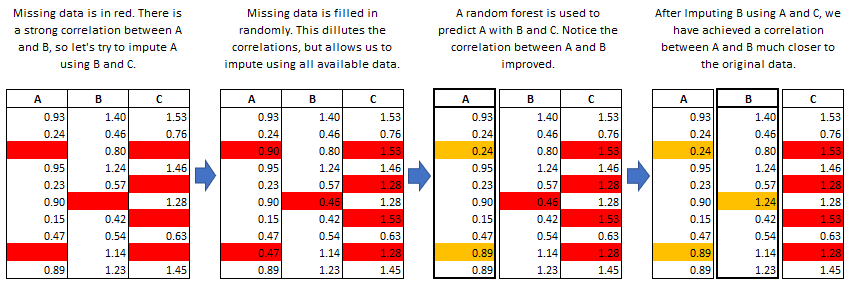

Fuente: https://cran.r-project.org/web/packages/miceRanger/vignettes/miceAlgorithm.html

#### **e. Completar con datos de fuentes externas**

Ejemplos:
* Tenemos un dataset de escuelas de todo el país. Dentro de otros atributos tenemos las coordenadas de la ubicación de la escuela (lat, long) y la provincia a la cual pertenece. Los valores faltantes en la variable *provincia* se pueden inferir a partir de las coordenadas recurriendo a información externa.
* Tenemos un registro de compras realizadas. Por cada compra tenemos los siguientes atributos: producto, fecha de compra, monto en pesos y monto en dólares. Si tenemos valores faltantes en la variable *monto en dólares*, es posible obtener a partir de fuentes externas la cotización del dólar al día de la compra y realizar la conversión a partir de la variable *monto en pesos*.


#### **f. Interpolación en series temporales**


In [ ]:
!gdown 1TArU65fhfQUxkel6FyPUYqGT6pdzijnJ

Downloading...
From: https://drive.google.com/uc?id=1TArU65fhfQUxkel6FyPUYqGT6pdzijnJ
To: /content/caudales_con_MV.csv
100% 3.17k/3.17k [00:00<00:00, 8.35MB/s]


In [ ]:
datos_caudales = pd.read_csv('/content/caudales_con_MV.csv')
datos_caudales['Fecha'] = pd.to_datetime(datos_caudales['Fecha'], format="%Y-%m-%d %H:%M")
datos_caudales.set_index('Fecha', inplace=True)
datos_caudales

,Caudal
Fecha,
2014-02-01 00:00:00,5600.0
2014-02-01 01:00:00,4260.0
2014-02-01 02:00:00,4391.0
2014-02-01 03:00:00,3277.0
2014-02-01 04:00:00,NaN
...,...
2014-02-06 19:00:00,5625.0
2014-02-06 20:00:00,5928.0
2014-02-06 21:00:00,6666.0


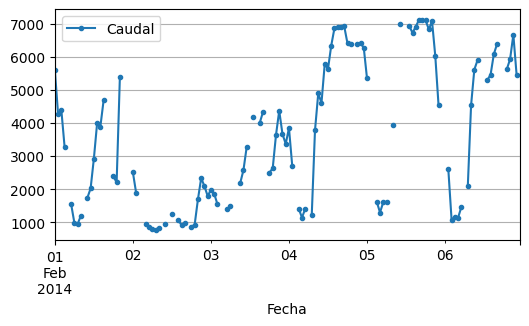

In [ ]:
datos_caudales.plot(style='.-', figsize=(6,3), grid=True);

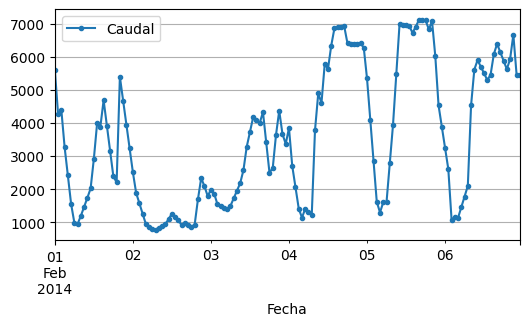

In [ ]:
datos_caudales_interpolados = datos_caudales.interpolate()
datos_caudales_interpolados.plot(style='.-', figsize=(6,3), grid=True);

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html

## Detección de valores atípicos *(outliers)*

**Outliers:** Datos alejados del patrón general del conjunto.

### **Análisis univariado**

#### **1. Boxplots**

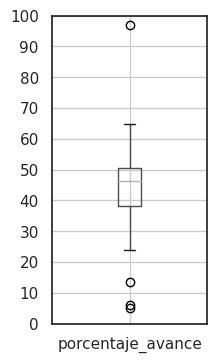

####**2. Z-score**

Indica cuántas desviaciones estándar un punto de datos específico está por encima o por debajo de la media del conjunto de datos.

\begin{align}
z = \frac{x - \bar{x}}{s_x}
\end{align}

$\bar{x}:$ media muestral

$s_x:$ desvío estándar muestral


**Umbral convencional = 3.0**

Asumiendo distribución normal, los datos dentro de 3 veces la desviación estándar respecto a la media representan el 99.7% de los datos de la distribución.

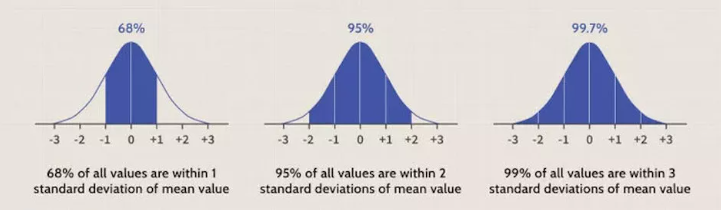



####**3. Z-score modificado**

Cuando los datos son asimétricos o no se distribuyen de forma normal podemos utilizar el z-score modificado. Mide cuánto se aleja un valor de la mediana en términos de la desviación absoluta mediana.


\begin{align}
M_i = \frac{0.6745(x - \tilde{x})}{MAD}
\end{align}

\begin{align}
MAD = mediana(|x_i - \tilde{x}|)
\end{align}

$\tilde{x}:$ mediana


$MAD:$ mediana de la desviación absoluta

Se suele utilizar un umbral de 3.5 como criterio para definir un dato como outlier.

#### **Inconveniente de los métodos univariados**

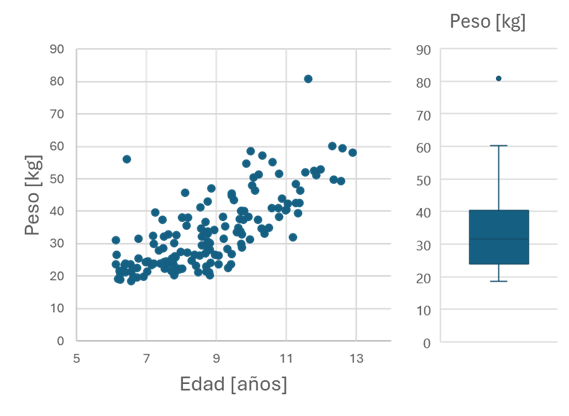



### Análisis multivariado

#### **1. Distancia de Mahalanobis**
Se diferencia de la distancia Euclideana por considerar la correlación entre las variables.

\begin{align}
d_M(\vec{x_a}, \vec{x_b}) = \sqrt{(\vec{x_a} - \vec{x_b})^T⋅S^{-1}\cdot(\vec{x_a} - \vec{x_b})}
\end{align}

$S:$ matriz de covarianza de $X$.

$\vec{x_a} = (x_{1a}, x_{2a}, x_{3a}, ..., x_{Na})$

$\vec{x_b} = (x_{1b}, x_{2b}, x_{3b}, ..., x_{Nb})$

\\

Si en lugar de calcular la distancia de Mahalanobis entre dos puntos A y B, calculamos la distancia entre un punto y el vector de medias $\vec{\mu}$, tenemos una medida de la distancia entre el punto y la distribución de $X$, que nos permite **detectar outliers**.

\begin{align}
D_M(\vec{x}) = \sqrt{(\vec{x} - \vec{\mu})^T⋅S^{-1}\cdot(\vec{x} - \vec{\mu})}
\end{align}

$\vec{\mu} = (\mu_1, \mu_2, \mu_3, ..., \mu_N)$


La distancia de Mahalanobis normaliza cada componente a varianza unitaria. Esto independiza la distancia de las escalas de las distintas componentes individuales. Además, reduce la influencia de variables altamente correlacionadas al tener en cuenta la redundancia de información que proporcionan esas variables en el cálculo de la distancia.


Por ejemplo, en el espacio euclideano 3D, una esfera determina los puntos equidistantes a su centro. En el caso de la distancia de Mahalanobis, se consideran elipsoides como equidistantes a un punto. El ancho de la elipsoide en cada uno de sus eje es proporcional a la varianza en esa dirección.

Ejemplo en 2D:

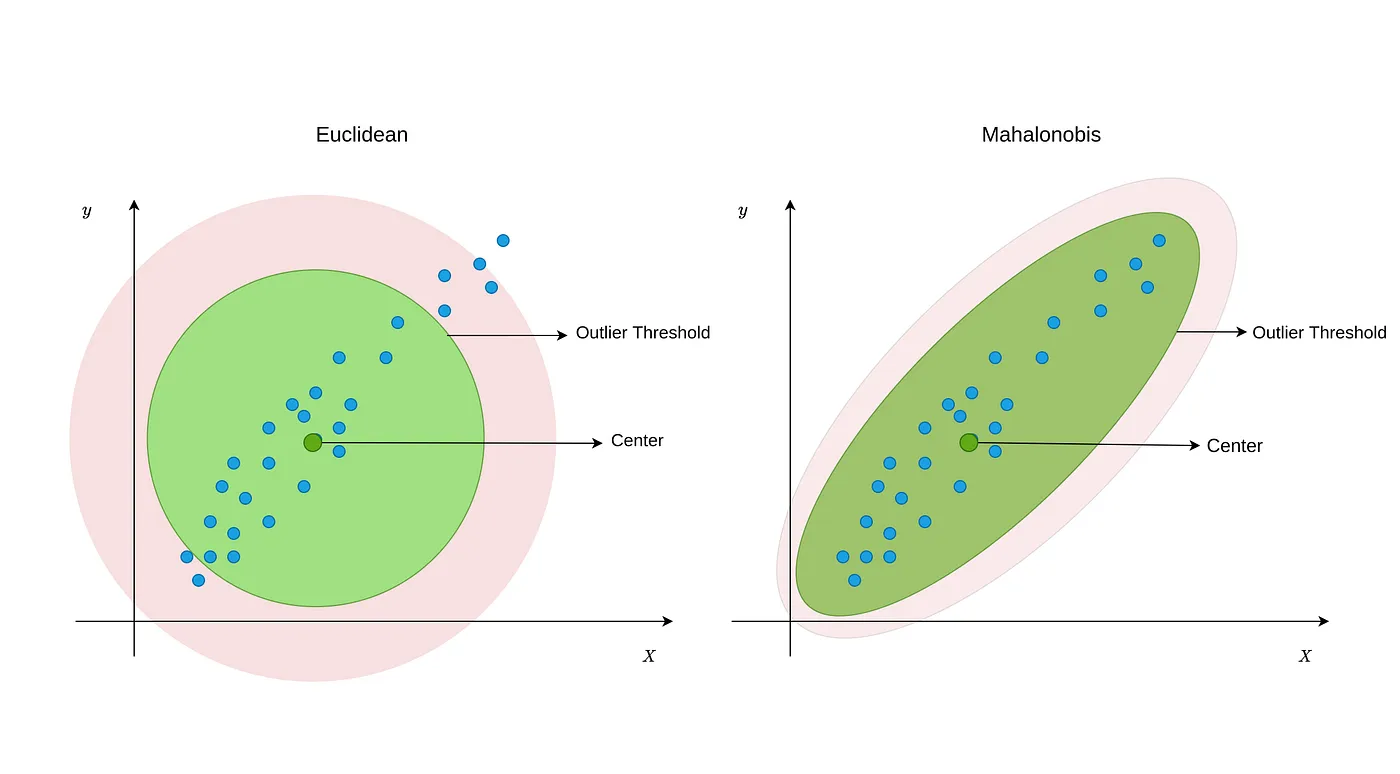

Fuente: https://towardsdatascience.com/multivariate-outlier-detection-in-python-e946cfc843b3

#### **2. Local Outlier Factor (LOF)**
Compara la densidad del vencindario de un punto con la densidad promedio de sus vecinos.

Paper donde se propone este método: https://dl.acm.org/doi/pdf/10.1145/342009.335388 (Breunig, 2000)


Es necesario definir:
- k
- distancia a utilizar (euclideana, de Mahalanobis, etc.).
- umbral de LOF para determinar si se trata o no de un outlier



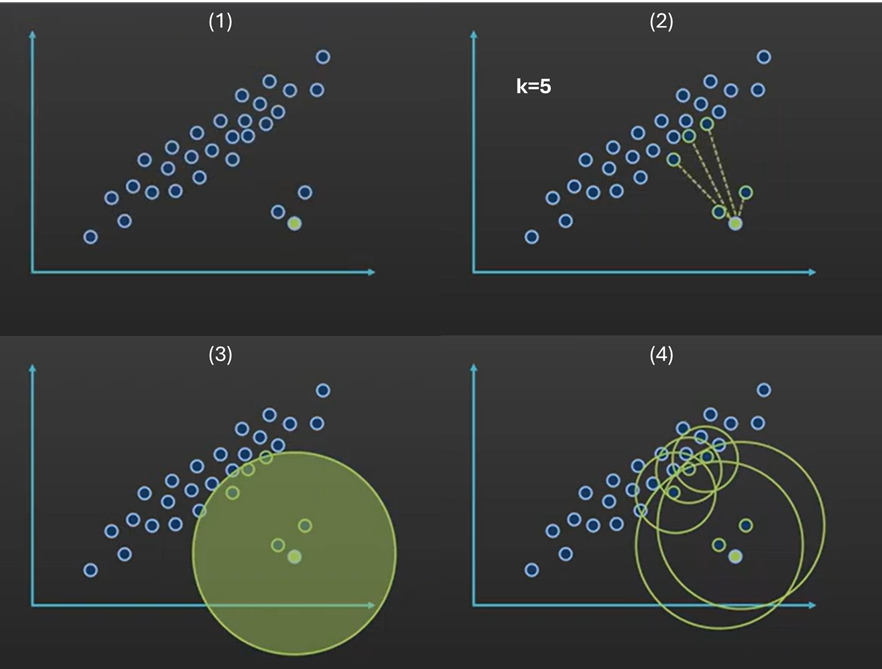

Fuente: [What is the Local Outlier Factor](https://www.youtube.com/watch?v=Ymvq6JHjoBY)

El método calcula *scores* para cada punto. Si es *score* del punto es 3, eso significa que la densidad promedio de los vecinos es 3 veces mayor que su densidad local.

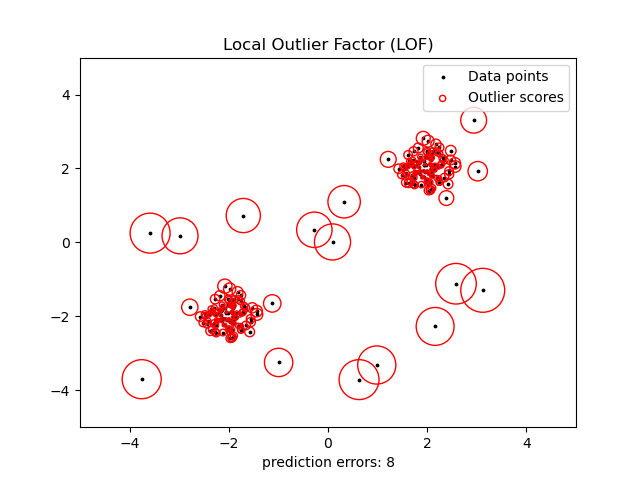

Fuente: https://scikit-learn.org/stable/auto_examples/neighbors/plot_lof_outlier_detection.html

#### **3. Isolation forest**

Se trata de un algoritmo eficiente para la detección de valores atípicos, sobre todo en bases de datos de alta dimensión. El algoritmo crea un ***random forest*** (lo vamos a ver más adelante) en el que los árboles de decisión crecen de manera aleatoria: en cada nodo, elige una característica de forma aleatoria y, a continuación, elige un valor de umbral aleatorio (entre los valores mínimo y máximo) para dividir el conjunto de datos en dos. El conjunto de datos se divide gradualmente en porciones, hasta que todas las instancias acaban aisladas respecto a las demás. **Las anomalías** suelen estar lejos de otras instancias, así que, de media (a través de todos los árboles de decisión), **tienden a quedar aisladas en menos pasos que las instancias normales**.

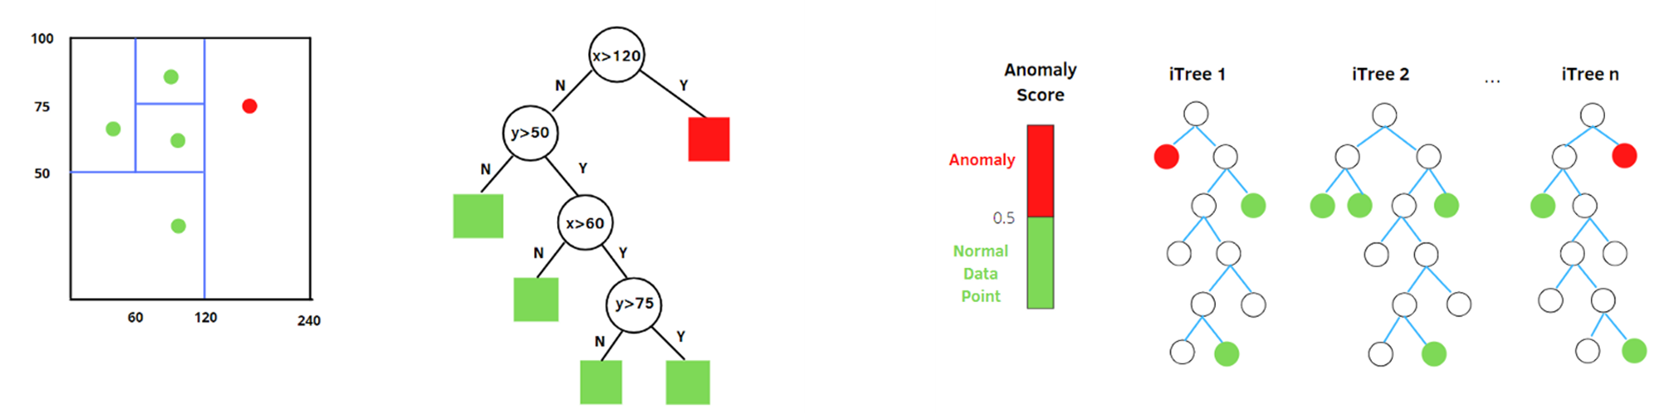

Fuente: https://betterprogramming.pub/anomaly-detection-with-isolation-forest-e41f1f55cc6

## Ingeniería de atributos

### Normalización de variables

Cuando trabajamos con un conjunto de datos, cada variable puede estar medida en escalas muy diferentes (por ejemplo, ingresos en miles y edades en años). Esto puede generar que unas variables tengan más peso que otras en los análisis o modelos.
Para evitarlo, aplicamos normalización, que consiste en transformar las variables a una escala común sin alterar la relación entre sus valores.

*   Evita que una variable tenga mayor influencia que otras en algoritmos que basados en distancias
*   Facilita la comparación entre variables
*   Mejora la convergencia en el entrenamiento en modelos como las redes neuronales.



* **Normalización Min-Max:**

\begin{align}
x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}
\end{align}

Rango de valores: [0; 1]

\\

* **Normalización Z-Score:**
\begin{align}
z = \frac{x - \bar{x}}{s_x}
\end{align}

$\bar{x}:$ media muestral

$s_x:$ desvío estándar muestral


### Binning
Dividir una variable continua en intervalos discretos (*bins*).

In [ ]:
df_libros = pd.DataFrame({'id_libro': range(1,21), 'precio': [18500,29900,25999,26900,16500,9900,11900,18500,26900,25990,18900,20000,20000,22999,19900,16500,17800,19700,25999,18500]}).set_index('id_libro')
df_libros.head()

,precio
id_libro,
1,18500
2,29900
3,25999
4,26900
5,16500


Los bins pueden definirse con distintos criterios:
- **Igual ancho** de bin: mismo tamaño de intervalo.
- **Igual frecuencia** en cada bin: misma cantidad de observaciones corresponden a cada intervalo.

Veamos los dos casos, adoptando un número de bins igual a 4.




**Igual ancho:**

 $ancho\_bin = \frac{max - min}{n_{bins}} = \frac{29900-9900}{4} = 5000$

 Bins resultantes:
 - [9900, 14900]
 - (14900, 19900]
 - (19900, 24900]
 - (24900, 29900]

In [ ]:
#data = df_libros.reset_index(drop=True)
df_libros['precio_bin'] = pd.cut(df_libros['precio'], bins=4)
df_libros

,precio,precio_bin
id_libro,,
1,18500,"(14900.0, 19900.0]"
2,29900,"(24900.0, 29900.0]"
3,25999,"(24900.0, 29900.0]"
4,26900,"(24900.0, 29900.0]"
5,16500,"(14900.0, 19900.0]"
6,9900,"(9880.0, 14900.0]"
7,11900,"(9880.0, 14900.0]"
8,18500,"(14900.0, 19900.0]"
9,26900,"(24900.0, 29900.0]"


In [ ]:
df_libros['precio_bin'].value_counts()

,count
precio_bin,
"(14900.0, 19900.0]",9
"(24900.0, 29900.0]",6
"(19900.0, 24900.0]",3
"(9880.0, 14900.0]",2


**Igual frecuencia:**

In [ ]:
df_libros = pd.DataFrame({'id_libro': range(1,21), 'precio': [18500,29900,25999,26900,16500,9900,11900,18500,26900,25990,18900,20000,20000,22999,19900,16500,17800,19700,25999,18500]}).set_index('id_libro')
df_libros.sort_values(by='precio')

,precio
id_libro,
6,9900
7,11900
5,16500
16,16500
17,17800
8,18500
20,18500
1,18500
11,18900


Si buscamos tener 4 bins de igual frecuencia, cada uno debería contener 5 muestras.
- [9900, 17800]
- (17800, 19700]
- (19700, 25990]
- (25990, 29900]


In [ ]:
df_libros['precio_bin_2'] = pd.qcut(df_libros['precio'], q=4)
df_libros

,precio,precio_bin_2
id_libro,,
1,18500,"(18325.0, 19800.0]"
2,29900,"(25992.25, 29900.0]"
3,25999,"(25992.25, 29900.0]"
4,26900,"(25992.25, 29900.0]"
5,16500,"(9899.999, 18325.0]"
6,9900,"(9899.999, 18325.0]"
7,11900,"(9899.999, 18325.0]"
8,18500,"(18325.0, 19800.0]"
9,26900,"(25992.25, 29900.0]"


Para cada intervalo vamos a setear un valor que puede ser:
- La media o mediana o el valor central del intervalo
- una etiqueta (ej: 'bajo', 'medio', 'alto', 'muy alto')
- una escala (ej: 1, 2, 3 ,4)

### Variables dummies
Muchos algortimos de aprendizaje automático no admiten variables categóricas. Una solución común a este problema, cuando el número de categorías posibles es limitado, es crear un atributo binario por cada categoría. Lo vemos con un ejemplo:

In [ ]:
datos_autos = {'id_auto': range(1,11),
               'modelo': [2016, 2012, 2017, 2015, 2020, 2019, 2021, 2018, 2010, 2014],
               'color': ['rojo', 'negro', 'negro', 'gris', 'rojo', 'blanco', 'negro', 'blanco', 'gris', 'blanco']}
datos_autos = pd.DataFrame(datos_autos).set_index('id_auto')
datos_autos

,modelo,color
id_auto,,
1,2016,rojo
2,2012,negro
3,2017,negro
4,2015,gris
5,2020,rojo
6,2019,blanco
7,2021,negro
8,2018,blanco
9,2010,gris


In [ ]:
datos_autos.color.unique()

array(['rojo', 'negro', 'gris', 'blanco'], dtype=object)

In [ ]:
pd.get_dummies(datos_autos, prefix='color', columns=['color'], dtype=int)

,modelo,color_blanco,color_gris,color_negro,color_rojo
id_auto,,,,,
1,2016,0,0,0,1
2,2012,0,0,1,0
3,2017,0,0,1,0
4,2015,0,1,0,0
5,2020,0,0,0,1
6,2019,1,0,0,0
7,2021,0,0,1,0
8,2018,1,0,0,0
9,2010,0,1,0,0


Teniendo en cuenta que por ejemplo, si sabemos que para determinado auto:
- color_gris = 0
- color_negro = 0
- color_rojo = 0

Entonces el color del auto va a ser **blanco**, por lo que no es necesario agregar la columna *color_blanco*.

Quedaría entonces de la siguiente forma:


In [ ]:
pd.get_dummies(datos_autos, prefix='color', columns=['color'], dtype=int, drop_first=True)

,modelo,color_gris,color_negro,color_rojo
id_auto,,,,
1,2016,0,0,1
2,2012,0,1,0
3,2017,0,1,0
4,2015,1,0,0
5,2020,0,0,1
6,2019,0,0,0
7,2021,0,1,0
8,2018,0,0,0
9,2010,1,0,0


El primer caso, donde por cada una de las categorías se crea una nueva variable, se llama **one-hot encoding**.

En segundo, donde una de las variables es omitida para evitar la redundancia, se trata de **variables dummies**.


En el caso de variables categóricas *ordinales*  pueden utilizarse esas opciones o bien, hacer un mapeo de las categorías a valores numéricos que respeten su ordinalidad. Por ejemplo:

Nivel de inglés:
- Básico -> 1
- Intermedio -> 2
- Avanzado -> 3

De esta manera podemos conservar representar toda la información en una única variable númerica (una sola columna, a diferencia de los casos anteriores).

### Creación de nuevas variables

Algunas posibilidades para la creación de nuevas variables:

**1. Operaciones entre variables existentes**

Ejemplos:
* Dataset de ventas de alimento balanceado. Variables existentes: nombre del producto, presentación (bolsa de cuántos kg), precio por unidad. Variable nueva: precio por kg.
* Dataset de recursos humanos de una empresa. Variables existentes: legajo y nombre del empleado, posición, salario, cantidad de horas semanales que trabaja. Variable nueva: salario/hora.

**2. Información externa**
Ejemplos:
* Precio del mismo producto al que lo ofrece el principal competidor.
* Salario promedio para esa posición en el mercado.




### Análisis de componentes principales (PCA)

*Fuente: Chan, D., Badano, C. I. & Rey, A. A. (2019). Análisis inteligente de datos con lenguaje R. edUTecNe. Disponible en: https://ria.utn.edu.ar/handle/20.500.12272/4371*


#### **Concepto y propósito:**

* El análisis de componentes principales es un procedimiento matemático mediante el cual se **transforma un conjunto de variables correlacionadas en un conjunto de variables no correlacionadas de menor dimensión que se obtienen a partir de combinaciones lineales de las variables originales**, de manera tal que se **preserve la mayor variabilidad** del conjunto original de observaciones. **A este nuevo conjunto de variables se lo denomina componentes principales.**

* PCA es una técnica exploratoria que no establece supuestos por lo tanto siempre puede aplicarse.

* El **propósito fundamental** de esta técnica consiste en la **reducción de la dimensión de los datos** con el fin de simplificar la magnitud del problema a estudiar. Además permite explorar la existencia de **variables latentes**.

\\

* Procura hallar aquellas **combinaciones lineales de las variables originales que maximizan la varianza.**

\begin{align}
Y_i = \sum_{j=1}^{p} a_{ij}X_j
\end{align}

\begin{align}
Y_i = a_{i1}X_1 + a_{i2}X_2 + ... + a_{ip}X_p
\end{align}


Siendo $a_i = (a_{i1}, a_{i2}, ..., a_{ip})$ con $||a_i||=1$. Los coeficientes $a_{ij}$ se denominan cargas.

* Entonces se empieza buscando el vector $a_1$ que maximice la varianza de $Y_1$.

* Para buscar la siguiente CP se busca $Y_2$ tal que maximice la varianza entre el conjunto de combinaciones lineales de las variables originales no correlacionadas con $Y_1$ (esto implica vector ortogonal a $a_1$).

#### **Desde el punto de vista geométrico:**





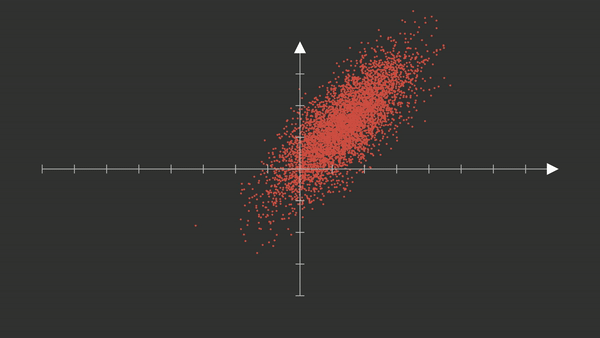




Fuente: https://medium.com/data-science/eigenvalues-and-eigenvectors-378e851bf372

#### **Desde el punto de vista matemático:**

* Se demuestra que la variabilidad de **la primera componente principal** es máxima cuando el vector de cargas $a_1$ es el **autovector asociado al mayor autovalor** de la matriz de varianzas y covarianzas.

* La variabilidad total del conjunto de datos es la suma de las varianzas de cada una de las variables, es decir, la traza de la matriz de covarianzas de las variables originales.

* Si las escalas de medida de las variables fueran muy diferentes, la variabilidad estaría dominada por las variables con mayores magnitudes de manera que las primeras componentes pueden mostrar simplemente las diferencias de escala de medición. Es por eso que **se trabaja en general con las variables estandarizadas**. En ese caso las componentes están calculadas sobre la **matriz de correlaciones**. (La matriz de correlación equivale a la matriz de covarianza de las variables estandarizadas).

*  La **proporción de la variabilidad** que capta la primera componente principal es: $\frac{λ_1}{tr(Σ)}$ siendo $λ_1$ el **autovalor** asociado a $a_1$.



#### **Ejemplo con 3 variables:**


* Descarga del dataset:

In [1]:
!gdown 10Wfu22uGTNPt9PRV2jTTr4zsJ4W_PWlU

Downloading...
From: https://drive.google.com/uc?id=10Wfu22uGTNPt9PRV2jTTr4zsJ4W_PWlU
To: /content/IMCinfantil.xlsx
100% 21.5k/21.5k [00:00<00:00, 28.3MB/s]


* Selección de variables

In [4]:
df = pd.read_excel('/content/IMCinfantil.xlsx')
df = df[['PESO', 'TALLA', 'CC']]
df.head()

,PESO,TALLA,CC
0,24.4,1.2,54
1,23.6,1.2,52
2,47.0,1.4,76
3,24.0,1.2,63
4,23.9,1.2,56


In [6]:
len(df)

150

In [5]:
df.cov().round(2)

,PESO,TALLA,CC
PESO,124.6,1.20,109.70
TALLA,1.2,0.02,0.96
CC,109.7,0.96,115.25


In [7]:
df.corr().round(2)

,PESO,TALLA,CC
PESO,1.00,0.87,0.92
TALLA,0.87,1.00,0.73
CC,0.92,0.73,1.00


* Visualización de las variables originales

In [8]:
# Datos de los puntos no normalizados
x = df.PESO
y = df.TALLA
z = df.CC

# Crea un scatterplot 3D con Plotly
scatter = go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=2,
        color='gray',  # Color de los puntos
        opacity=0.8
    )
)

# Configura el layout del gráfico
layout = go.Layout(
    scene=dict(
        xaxis=dict(title='PESO [kg]', range=[0, 100]),
        yaxis=dict(title='TALLA [m]', range=[0, 100]),
        zaxis=dict(title='CC [cm]', range=[0, 100])
    ),
    title='Datos iniciales'
)

# Crear la figura con los datos y vectores
fig = go.Figure(data=scatter, layout=layout)

# Muestra el gráfico interactivo
fig.show()

* Estandarización de variables

In [9]:
df_norm = pd.DataFrame()
df_norm['PESO_n'] = (df.PESO - df.PESO.mean())/(df.PESO.std())
df_norm['TALLA_n'] = (df.TALLA - df.TALLA.mean())/(df.TALLA.std())
df_norm['CC_n'] = (df.CC - df.CC.mean())/(df.CC.std())
df_norm.head()

,PESO_n,TALLA_n,CC_n
0,-0.806268,-0.987126,-1.047630
1,-0.877936,-0.987126,-1.233931
2,1.218360,0.629347,1.001676
3,-0.842102,-0.987126,-0.209278
4,-0.851060,-0.987126,-0.861330


In [10]:
df_norm.cov().round(2)

,PESO_n,TALLA_n,CC_n
PESO_n,1.00,0.87,0.92
TALLA_n,0.87,1.00,0.73
CC_n,0.92,0.73,1.00


In [11]:
df_norm.corr().round(2)

,PESO_n,TALLA_n,CC_n
PESO_n,1.00,0.87,0.92
TALLA_n,0.87,1.00,0.73
CC_n,0.92,0.73,1.00


* Visualización de los datos estandarizados

In [12]:
# Datos de los puntos normalizados
x = df_norm.PESO_n
y = df_norm.TALLA_n
z = df_norm.CC_n

# Crea un scatterplot 3D con Plotly
scatter = go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=2,
        color='gray',  # Color de los puntos
        opacity=0.8
    )
)

# Configura el layout del gráfico
layout = go.Layout(
    scene=dict(
        xaxis=dict(title='PESO norm', range=[-4, 4]),
        yaxis=dict(title='TALLA norm', range=[-4, 4]),
        zaxis=dict(title='CC norm', range=[-4, 4])
    ),
    title='Datos estandarizados'
)

# Crear la figura con los datos y vectores
fig = go.Figure(data=scatter, layout=layout)

# Muestra el gráfico interactivo
fig.show()

• **Implementación PCA**

Dirección de las componentes principales:

In [13]:
pca = PCA(n_components=3)
new_var = pca.fit_transform(df_norm)
pca.components_ # cuánto pesa cada variable original en ese componente.

array([[ 0.60159252,  0.55904155,  0.57057776],
       [-0.08584429,  0.75540002, -0.64961648],
       [ 0.79417705, -0.34182358, -0.50243353]])

In [16]:
new_var

array([[-1.63464371e+00,  4.09651944e-03,  2.23468264e-01],
       [-1.78405778e+00,  1.31272778e-01,  2.60154667e-01],
       [ 1.65632151e+00, -2.79886196e-01,  2.49192358e-01],
       [-1.17785580e+00, -5.37435100e-01, -2.26206914e-01],
       [-1.55529164e+00, -1.13082237e-01,  9.42912924e-02],
       [ 1.43925741e+00, -3.54767828e-01, -2.71290871e-01],
       [ 7.25341050e-02, -3.58409656e-01, -1.50087499e-01],
       [-1.84873039e+00,  1.40501242e-01,  1.74778756e-01],
       [-6.32165510e-01,  2.18497741e-01, -2.76866445e-02],
       [-8.30666810e-03, -3.46874077e-01, -2.56807387e-01],
       [-6.21386741e-01,  2.16959664e-01, -1.34573261e-02],
       [ 2.73320155e+00,  9.69409621e-01,  4.22614280e-02],
       [-1.29839508e+00,  8.42843456e-01,  2.62465255e-01],
       [ 3.36573239e+00, -4.83927606e-01,  2.29481885e-01],
       [-1.00793374e+00,  3.77973622e-01, -2.89815930e-01],
       [-1.13682398e-01, -5.43548697e-01, -8.63779633e-01],
       [ 3.10419845e+00,  1.59148693e+00

Proyección de los datos estandarizados en las componentes principales:

In [17]:
new_var = pd.DataFrame(new_var, columns=['PC1', 'PC2', 'PC3'])
new_var.head()

,PC1,PC2,PC3
0,-1.634644,0.004097,0.223468
1,-1.784058,0.131273,0.260155
2,1.656322,-0.279886,0.249192
3,-1.177856,-0.537435,-0.226207
4,-1.555292,-0.113082,0.094291


• Visualización de las direcciones de las componentes principales

In [18]:
# Datos de los puntos normalizados
x = df_norm.PESO_n
y = df_norm.TALLA_n
z = df_norm.CC_n

# Crea un scatterplot 3D con Plotly
scatter = go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=2,
        color='gray',  # Color de los puntos
        opacity=0.8
    )
)

# Define las direcciones de las componentes principales
components = pca.components_
explained_variance = pca.explained_variance_

# Lista para almacenar los vectores de las componentes principales
vectors = []

# Origen (0,0,0)
origin = np.array([0, 0, 0])

# Dibujar los vectores correspondientes a cada componente principal
for i in range(components.shape[0]):
    vector = components[i] * np.sqrt(explained_variance[i])  # Escalado según varianza
    vectors.append(
        go.Scatter3d(
            x=[origin[0], vector[0]],
            y=[origin[1], vector[1]],
            z=[origin[2], vector[2]],
            mode='lines',
            line=dict(
                width=6,
                color=['red', 'green', 'blue'][i]  # Color diferente para cada vector
            ),
            name=f'PC{i+1}'
        )
    )

# Configura el layout del gráfico
layout = go.Layout(
    scene=dict(
        xaxis=dict(title='PESO norm', range=[-4, 4]),
        yaxis=dict(title='TALLA norm', range=[-4, 4]),
        zaxis=dict(title='CC norm', range=[-4, 4])
    ),
    title='Datos estandarizados y dirección de las componentes principales'
)

# Crear la figura con los datos y vectores
fig = go.Figure(data=[scatter] + vectors, layout=layout)

# Muestra el gráfico interactivo
fig.show()

• Visualización de los datos en el espacio de las componentes principales

In [19]:
# Datos de los puntos normalizados
x = new_var.PC1
y = new_var.PC2
z = new_var.PC3

# Crea un scatterplot 3D con Plotly
scatter = go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=2,
        color='gray',  # Color de los puntos
        opacity=0.8
    )
)

# Configura el layout del gráfico
layout = go.Layout(
    scene=dict(
        xaxis=dict(title='PC1', range=[-4, 4]),
        yaxis=dict(title='PC2', range=[-4, 4]),
        zaxis=dict(title='PC3', range=[-4, 4])
    ),
    title='Datos normalizados y dirección de las componentes principales'
)

# Crear la figura con los datos y vectores
fig = go.Figure(data=scatter, layout=layout)

# Muestra el gráfico interactivo
fig.show()

Vemos que las nuevas variables no están correlacionadas tanto en la matriz de correlació como gráficamente:

In [20]:
new_var.corr().round(2)

,PC1,PC2,PC3
PC1,1.0,-0.0,0.0
PC2,-0.0,1.0,0.0
PC3,0.0,0.0,1.0


(-5.0, 5.0)

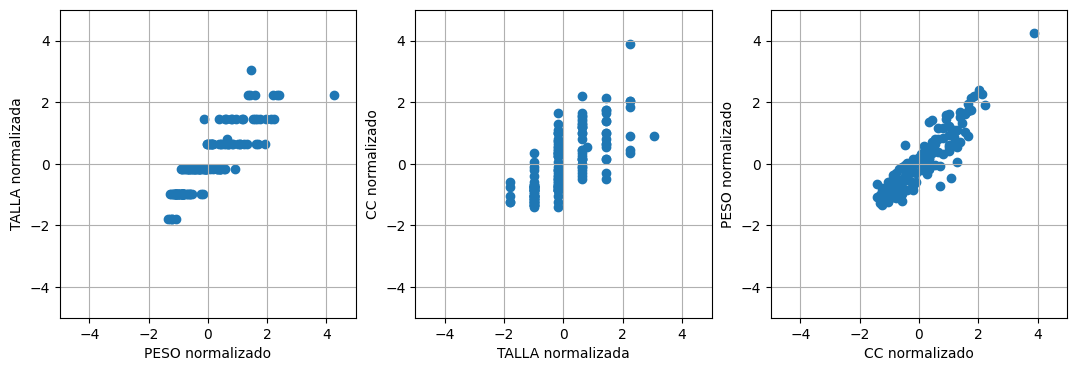

In [21]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(13,4))

axs[0].scatter(x = df_norm.PESO_n, y = df_norm.TALLA_n)
axs[0].grid()
axs[0].set_xlabel('PESO normalizado')
axs[0].set_ylabel('TALLA normalizada')
axs[0].set_xlim(-5,5)
axs[0].set_ylim(-5,5)

axs[1].scatter(x = df_norm.TALLA_n, y = df_norm.CC_n)
axs[1].grid()
axs[1].set_xlabel('TALLA normalizada')
axs[1].set_ylabel('CC normalizado')
axs[1].set_xlim(-5,5)
axs[1].set_ylim(-5,5)

axs[2].scatter(x = df_norm.CC_n, y = df_norm.PESO_n)
axs[2].grid()
axs[2].set_xlabel('CC normalizado')
axs[2].set_ylabel('PESO normalizado')
axs[2].set_xlim(-5,5)
axs[2].set_ylim(-5,5)

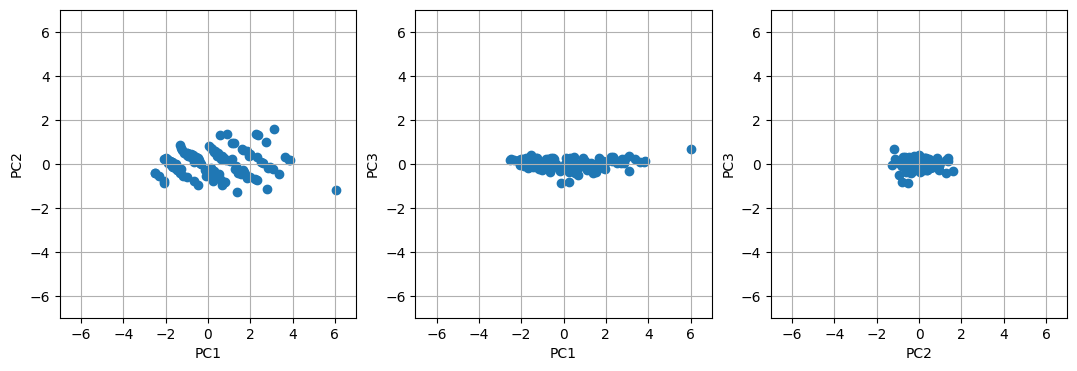

In [ ]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(13,4))

axs[0].scatter(x = new_var.PC1, y = new_var.PC2)
axs[0].grid()
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_xlim(-7,7)
axs[0].set_ylim(-7,7);

axs[1].scatter(x = new_var.PC1, y = new_var.PC3)
axs[1].grid()
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC3')
axs[1].set_xlim(-7,7)
axs[1].set_ylim(-7,7);

axs[2].scatter(x = new_var.PC2, y = new_var.PC3)
axs[2].grid()
axs[2].set_xlabel('PC2')
axs[2].set_ylabel('PC3')
axs[2].set_xlim(-7,7)
axs[2].set_ylim(-7,7);

• **Varianza explicada por cada componente principal**

In [22]:
pca.explained_variance_.round(2)

array([2.68, 0.28, 0.05])

Son los autovalores ordenados de la matriz de covarianza (si trabajamos con datos estandarizados coincide con la matriz de correlación).

In [ ]:
np.linalg.eig(df_norm.cov()).eigenvalues.round(2)

array([2.68, 0.05, 0.28])

Coincide también con la varianza de los datos en el espacio de las nuevas componentes:

In [23]:
var_explicada = new_var.var().round(2)
var_explicada

,0
PC1,2.68
PC2,0.28
PC3,0.05


Porcentaje de la variable explicada de cada componente principal:

In [ ]:
pct_var_explicada = new_var.var()*100/(new_var.var().sum())
pct_var_explicada.round(2)

,0
PC1,89.20
PC2,9.24
PC3,1.56


#### **Reducción de dimensionalidad: ¿con cuántas componentes me quedo?**
Se espera que solo unas pocas (las primeras) recojan la mayor parte de la variabilidad de los datos. Opciones para definir cuántas:
  * Definir un porcentaje mínimo de varianza explicada (por ejemplo, 80%). Nos quedamos con las primeras CP que sumen ese porcentaje.
  * Criterio del bastón roto: Observar gráficamente si la variabilidad explicada se estabiliza a partir de un determinado número de CP. Es decir, si aumento una dimensión más, la varianza explicada no aumenta significativamente.

Ejemplo con otro dataset de 10 variables:

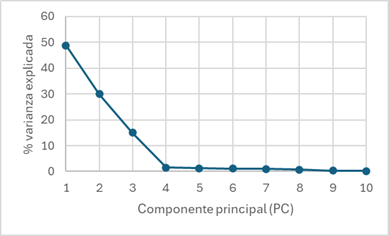

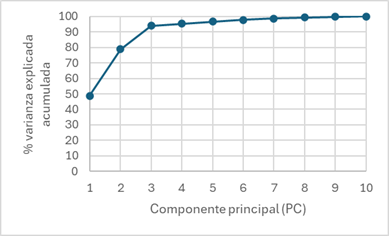

## Ejercicio práctico: dataset de propiedades

En el siguiente ejemplo exploraremos un dataset de propiedades de Properati con registros hasta julio de 2021 (https://github.com/daterxs/datos-imobiliario/releases/tag/properati-julio-2021)

### Descarga del dataset

In [ ]:
# dataset Properati Julio 2021
!gdown 1-B93jjaUuZpxhsJsLJzL9CXNLQ8eIY5w

Downloading...
From (original): https://drive.google.com/uc?id=1-B93jjaUuZpxhsJsLJzL9CXNLQ8eIY5w
From (redirected): https://drive.google.com/uc?id=1-B93jjaUuZpxhsJsLJzL9CXNLQ8eIY5w&confirm=t&uuid=f81aa19b-1549-43f8-a4a6-28268b51e918
To: /content/ar_properties.csv.gz
100% 299M/299M [00:04<00:00, 71.0MB/s]


In [ ]:
# Descomprimimos el archivo
properati = pd.read_csv('ar_properties.csv.gz',compression='gzip',
                                 header=0, sep=',', quotechar='"')


In [ ]:
df = properati.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 25 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   id               1000000 non-null  object 
 1   ad_type          1000000 non-null  object 
 2   start_date       1000000 non-null  object 
 3   end_date         1000000 non-null  object 
 4   created_on       1000000 non-null  object 
 5   lat              891107 non-null   float64
 6   lon              890983 non-null   float64
 7   l1               1000000 non-null  object 
 8   l2               1000000 non-null  object 
 9   l3               964640 non-null   object 
 10  l4               301687 non-null   object 
 11  l5               6172 non-null     object 
 12  l6               0 non-null        float64
 13  rooms            704748 non-null   float64
 14  bedrooms         651959 non-null   float64
 15  bathrooms        766586 non-null   float64
 16  surface_total    46

In [ ]:
registros_1 = len(df)

In [ ]:
df.sample(8)

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
320065,4Cg+2l+8HiQlZBjv4FkFCw==,Propiedad,2020-06-03,2020-06-15,2020-06-03,-34.652934,-58.623641,Argentina,Bs.As. G.B.A. Zona Oeste,Morón,...,1.0,32.0,30.0,12000.0,ARS,Mensual,Departamento de un ambiente en alquiler - Moro...,Departamento de un ambiente. Excelente ubicac...,Departamento,Alquiler
742711,lj30MQ+Z+q2HAwkyxdA7IQ==,Propiedad,2021-04-15,2021-06-05,2021-04-15,NaN,NaN,Argentina,Bs.As. G.B.A. Zona Norte,Escobar,...,NaN,NaN,NaN,150000.0,USD,Mensual,LOTE AL AGUA | VENTA | BARRIO SAN MATÍAS | MAS...,LOTE AL AGUA | VENTA | BARRIO SAN MATÍAS | MAS...,Lote,Venta
90411,aCEiSxUMxluxEhrIJtA1ew==,Propiedad,2021-01-13,2021-02-26,2021-01-13,NaN,NaN,Argentina,Capital Federal,Palermo,...,1.0,48.0,43.0,35000.0,ARS,NaN,Departamento de 2 ambientes en Alquiler en Pal...,DEPARTAMENTO 2 AMBIENTES AMPLIOS AL FRENTE CON...,Departamento,Alquiler
845299,36Ac408YqDmBtfZ5v7fKKw==,Propiedad,2020-09-22,9999-12-31,2020-09-22,-34.600294,-58.455016,Argentina,Capital Federal,Villa Crespo,...,3.0,150.0,145.0,215000.0,USD,Mensual,Esquina CASA/OFICINA CON PATIO en la mejor zon...,EXCELENTE INMUEBLE de 150 m2 en zona WARNES. S...,Casa,Venta
7746,97Tv9/t/EsJVNGAqDsjwuw==,Propiedad,2021-05-16,2021-05-18,2021-05-16,-31.425775,-64.178854,Argentina,Córdoba,Córdoba,...,1.0,75.0,75.0,75000.0,USD,Mensual,Departamento de 2 dormitorios con cochera en P...,Departamento 75m² en Departamento de 2 dormito...,Departamento,Venta
539052,D8fRQQDCqOq4DAbvgZ4u9A==,Propiedad,2020-08-20,2020-09-04,2020-08-20,-34.473223,-58.522850,Argentina,Bs.As. G.B.A. Zona Norte,San Isidro,...,1.0,56.0,55.0,159000.0,USD,NaN,Venta Excelente 2 Ambientes en Suite con Cochera,Corredor Responsable: Luis Schirripa - CSI 651...,Departamento,Venta
379238,m0mlMyx0WILPKDPgXUg4aA==,Propiedad,2020-06-04,2020-06-25,2020-06-04,-34.535311,-58.524674,Argentina,Bs.As. G.B.A. Zona Norte,Vicente López,...,1.0,78.0,70.0,139000.0,USD,Mensual,Departamento - Florida,EXCELENTE DEPARTAMENTO DE 2 AMBIENTES.<br>2 am...,Departamento,Venta
898510,EL5+uEusO+UOAB55iiaJlg==,Propiedad,2020-12-02,2021-06-29,2020-12-02,-34.887072,-57.886365,Argentina,Buenos Aires Interior,Berisso,...,1.0,291.0,86.0,43000.0,USD,NaN,Casa en Venta Berisso,"Casa sobre esquina con dos habitaciones, pati...",Casa,Venta


### Exploración del dataset

In [ ]:
# Exploración de variables
for column in df.columns:
  print('---------------')
  print('---------------')
  print(df[column].value_counts())
  print('---------------')

---------------
---------------
id
i+IA5toy2A9Bn4S35pT8Jw==    1
wmqSavUto2479sYLBigsvQ==    1
aa+li7zfcY0X/xEEsnPTMQ==    1
2hXXbKTCmQ8mApZeyt3/8w==    1
bN8cwRb0DOTskRhlxcuQlw==    1
                           ..
YHn9/2Is/Y5MIZljNGehTQ==    1
I3hI7Y2buDUHc05E2cQyRg==    1
U3QiwOIgGgGI3zJ1T74tLQ==    1
r4OJdo+XUJOwUbNH/E9dcA==    1
KOcd6rVCXK8Pvbslzde2Bg==    1
Name: count, Length: 1000000, dtype: int64
---------------
---------------
---------------
ad_type
Propiedad    1000000
Name: count, dtype: int64
---------------
---------------
---------------
start_date
2021-03-26    10371
2020-11-07     9714
2020-08-04     9661
2020-04-29     9230
2020-06-26     8574
              ...  
2020-08-22      356
2021-02-07      346
2020-12-26      308
2021-01-24      304
2020-12-25      237
Name: count, Length: 365, dtype: int64
---------------
---------------
---------------
end_date
9999-12-31    210146
2021-06-05     57373
2021-04-09     23440
2020-09-04     15848
2021-06-08     14177
         

Visualización rápida de las variables:
- `id`: id único para cada publicación
- `ad_type`: son "Propiedades" en todos los registros. Redundante. Se elimina.
- `start_date`: fecha de inicio de la publicación
- `end_date`: fecha de fin de la publicación. **Muchos registros con fecha 9999-12-31, lo cual es un error. ¿Puede deberse a publicaciones activas al armar el dataset?**
- `created_on`: la columna es idéntica a `start_date`. Se elimina ya que es redundante.
- `lat`: latitud. Punto georreferenciado
- `lon`: longitud. Punto georreferenciado
- `l1`,`l2`,`l3`,`l4`,`l5`,`l6`: jerarquías de ubicación de la propiedad. Se distingue en orden decreciente `Pais, Provincia o Región, ¿Ciudad?/¿Barrio?,¿Ciudad?, Barrio Privado (si corresponde), Vacío`. Debemos analizar con detalle estas variables.
- `rooms`: cantidad de habitaciones. Se identifican valores atípicos
- `bedrooms`: cantidad de cuartos. Se identifican valores atípicos
- `bathrooms`: cantidad de baños. Se identifican valores atípicos
- `surface_total`: superficie total. **Variable relevante (conocimiento de dominio)**
- `surface_covered`: superficie cubierta. **Variable relevante (conocimiento de dominio)**
- `price`: precio. **Será la variable que buscamos predecir y por la cual hacemos el feature engineering necesario**
- `currency`: moneda
- `price_period`: período de precio. Puede ser semanal o diario pero la gran mayoría toma "Mensual" si toma valor.
- `title`, `description`: campos de texto relevantes asociados a la publicación online y lo que coloque el propietario/inmobiliaria.
- `property_type`: nos describe el tipo de propiedad de un listado
- `operation_type`: si se trata de una venta, alquiler o alquiler temporal.

### Objetivo

El objetivo del feature engineering que haremos es consolidar el dataset para **buscar predecir el precio de venta de propiedades ubicadas en CABA y el AMBA que sean departamentos, casas, PH, casas de campo**

*Por simplicidad, nos quedaremos con publicaciones en dólares*

In [ ]:
df.groupby(['operation_type','currency'])['currency'].count()

operation_type     currency
Alquiler           ARS         175671
                   PEN            128
                   USD          22929
                   UYU           2585
Alquiler temporal  ARS          19295
                   PEN              1
                   USD          19307
                   UYU             32
Venta              ARS          22354
                   COP              3
                   PEN            151
                   USD         695714
                   UYU              4
Name: currency, dtype: int64

In [ ]:
df[df['property_type'] == 'Otro']

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
5,BduCuWcBIkCFsInTrjc+ZQ==,Propiedad,2021-02-07,2021-06-01,2021-02-07,-37.384124,-68.918824,Argentina,Neuquén,Rincón de los Sauces,...,NaN,7350.0,380.0,NaN,NaN,Mensual,"Alquilo base, con galpones en Rincón de los Sa...","Inmobiliaria De La Via, ALQUILA, base en Rincó...",Otro,Alquiler
6,zEs9lZzaZifDvEGksuUfsQ==,Propiedad,2021-02-07,2021-06-01,2021-02-07,-37.396398,-68.905745,Argentina,Neuquén,Rincón de los Sauces,...,NaN,4747.0,428.0,NaN,NaN,Mensual,Vendo base petrolera en Rincón de los Sauces.,"Inmobiliaria De La Via, ALQUILA, base en Rincó...",Otro,Venta
7,lZgo3cEVBLHDNW9FMAJfgg==,Propiedad,2021-02-07,2021-06-01,2021-02-07,-37.386374,-68.958585,Argentina,Neuquén,Rincón de los Sauces,...,NaN,60000.0,180.0,NaN,NaN,Mensual,Alquilo Base en Rincón de los Sauces.,"Inmobiliaria De La Via, ALQUILA, base en Rincó...",Otro,Alquiler
8,1jdD1KaiJnRNI++d92QiUg==,Propiedad,2021-02-07,2021-06-01,2021-02-07,-37.405382,-68.910777,Argentina,Neuquén,Rincón de los Sauces,...,NaN,1000.0,1000.0,NaN,NaN,Mensual,Alquilo Galpón de 1.000 m2. en Rincón de los S...,"Inmobiliaria De La Via, ALQUILA, Galpón en Rin...",Otro,Alquiler
14,jMu79lFyBlAApQWPScfrMg==,Propiedad,2021-02-07,9999-12-31,2021-02-07,-32.352512,-64.998494,Argentina,San Luis,NaN,...,1.0,NaN,NaN,NaN,NaN,Mensual,Suite Majo - Suite para 1 a 2 personas con pil...,Suite Majo - Suite para 1 a 2 personas con pil...,Otro,Alquiler temporal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999412,sT1h4lz5PvjsSMjCVGAy5A==,Propiedad,2020-09-11,9999-12-31,2020-09-11,-34.560890,-58.452093,Argentina,Capital Federal,Belgrano,...,5.0,NaN,NaN,NaN,NaN,NaN,Venta 4 Dormitorios. Dependencia y Dos Cochera...,[RETASADO] Hermoso Piso en Venta en Barrancas ...,Otro,Venta
999448,qZorHEFvhEn7p/p3i6nb1Q==,Propiedad,2020-09-11,9999-12-31,2020-09-11,-34.313503,-58.796736,Argentina,Bs.As. G.B.A. Zona Norte,Escobar,...,4.0,NaN,250.0,230000.0,USD,Mensual,Quinta - Escobar,PRECIOSA CASA QUINTA EN Bº MARIA PROVIDENCIA<b...,Otro,Venta
999501,i3xmaaDwBuPw3wXEdlB45w==,Propiedad,2020-09-11,2020-12-03,2020-09-11,-34.624047,-58.383541,Argentina,Capital Federal,Constitución,...,NaN,495.0,495.0,198000.0,USD,NaN,VENTA HOTEL CONSTITUCIÓN OPORTUNIDAD,Corredor Responsable: Maria Badino - CUCICBA ...,Otro,Venta
999554,3dEqpVzIb03pfHemb463Lw==,Propiedad,2020-09-11,2020-12-11,2020-09-11,-34.652944,-58.409093,Argentina,Capital Federal,Pompeya,...,NaN,501.0,501.0,380000.0,USD,Mensual,Beazley 3500 y A. Alcorta Pompeya Galpon en es...,"Gran esquina, ubicada dentro del polo tecnolog...",Otro,Venta


In [ ]:
print('Cantidad de nulos de la columna de tipo de propiedades: ',df['property_type'].isna().sum())

Cantidad de nulos de la columna de tipo de propiedades:  0


Como la columna no tiene nulos y el campo 'Otros' agrupa distintos tipos de propiedades (entre los cuales se observa que puede haber registros que nos sirvan), se decide por simplificación en este caso no tomar esos registros y asumir que se imputaron OK los valores en cada categoría.

In [ ]:
#Recorte del dataset
df.drop(df[~df['property_type'].isin(['Departamento','Casa','PH','Casa de campo'])].index,inplace=True)
df.drop(df[~df['l1'].isin(['Argentina'])].index, inplace=True)
df.drop(df[~df['l2'].isin(['Capital Federal','Bs.As. G.B.A. Zona Norte','Bs.As. G.B.A. Zona Sur','Bs.As. G.B.A. Zona Oeste'])].index, inplace = True)
df.drop(df[~df['operation_type'].isin(['Venta'])].index, inplace = True)
df.drop(df[~df['currency'].isin(['USD'])].index, inplace = True)




In [ ]:
df['property_type'].value_counts()

,count
property_type,
Departamento,217579
Casa,121801
PH,26832
Casa de campo,903


In [ ]:
df['l2'].value_counts()

,count
l2,
Capital Federal,154127
Bs.As. G.B.A. Zona Norte,92547
Bs.As. G.B.A. Zona Sur,73952
Bs.As. G.B.A. Zona Oeste,46489


Veo la proporción de nulos del dataframe

In [ ]:
for columna in df.columns:
  print('--------------')
  nulos = df[columna].isna().sum()
  proporcion = nulos/len(df)
  print(f'La columna {columna} tiene {nulos} valores nulos, representando un {round(proporcion*100,2)}% del total de los registros')
  print('--------------')

--------------
La columna id tiene 0 valores nulos, representando un 0.0% del total de los registros
--------------
--------------
La columna ad_type tiene 0 valores nulos, representando un 0.0% del total de los registros
--------------
--------------
La columna start_date tiene 0 valores nulos, representando un 0.0% del total de los registros
--------------
--------------
La columna end_date tiene 0 valores nulos, representando un 0.0% del total de los registros
--------------
--------------
La columna created_on tiene 0 valores nulos, representando un 0.0% del total de los registros
--------------
--------------
La columna lat tiene 34220 valores nulos, representando un 9.32% del total de los registros
--------------
--------------
La columna lon tiene 34275 valores nulos, representando un 9.34% del total de los registros
--------------
--------------
La columna l1 tiene 0 valores nulos, representando un 0.0% del total de los registros
--------------
--------------
La columna l2 tien

In [ ]:
df

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
94,h+hlQPYAneUMmL/hnCElmA==,Propiedad,2021-02-07,9999-12-31,2021-02-07,-34.570974,-58.488661,Argentina,Capital Federal,Villa Urquiza,...,NaN,149.0,111.0,295000.0,USD,Mensual,Ph venta,Vendemos nuestro hermoso PH de diseño moderno ...,PH,Venta
106,fXwIdi+lef1DAgzty+pgBw==,Propiedad,2021-02-07,9999-12-31,2021-02-07,-34.573578,-58.467787,Argentina,Capital Federal,Belgrano,...,8.0,NaN,NaN,2200000.0,USD,NaN,"Casa Chalet en Venta ubicado en Belgrano R, C...",Amplísima casa de GRAN CATEGORÍA en una zona p...,Casa,Venta
139,YG+y9RGCAsi/iERC4y0NXA==,Propiedad,2021-02-07,9999-12-31,2021-02-07,-34.595487,-58.409780,Argentina,Capital Federal,NaN,...,NaN,82.0,80.0,215000.0,USD,Mensual,Departamento venta,*** DUEÑO DIRECTO *** SIN COMISIÓN ***\r\n\r\n...,Departamento,Venta
140,iWfpw9H4LvXJU++jARL0Fg==,Propiedad,2021-02-07,2021-04-07,2021-02-07,NaN,NaN,Argentina,Bs.As. G.B.A. Zona Oeste,Morón,...,1.0,33.0,31.0,45000.0,USD,Mensual,Departamento de 1 ambiente en Moron Sur,"Monoambiente de 32 m2. Muy buen estado, ampl...",Departamento,Venta
141,RH+CFih0Mo3Skh50R/ctTQ==,Propiedad,2021-02-07,2021-07-10,2021-02-07,NaN,NaN,Argentina,Capital Federal,Belgrano,...,NaN,NaN,NaN,1932000.0,USD,Mensual,Departamento - Belgrano,<br><br>Las visitas a esta propiedad se realiz...,Departamento,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,aMdWul4lb0cft7bT7ugIvw==,Propiedad,2020-09-11,2020-12-11,2020-09-11,-34.592797,-58.406325,Argentina,Capital Federal,Recoleta,...,3.0,135.0,122.0,299000.0,USD,Mensual,Laprida 1300 Recoleta 5amb frente baul coch u$...,Bajo de precio! Semipiso al frente de 5 ambie...,Departamento,Venta
999996,51E7x6pmEzkK0T0H7U0HYA==,Propiedad,2020-09-11,2020-12-11,2020-09-11,-34.596805,-58.400352,Argentina,Capital Federal,Recoleta,...,3.0,108.0,98.0,269000.0,USD,Mensual,Azcuénaga 1000 Recoleta 5amb U$269.000 Apto Prof,"Apto profesional. Semipiso de 5 ambientes, al ...",Departamento,Venta
999997,utmt1ScUMon2vM337zRImg==,Propiedad,2020-09-11,2020-12-11,2020-09-11,NaN,NaN,Argentina,Capital Federal,Flores,...,3.0,170.0,150.0,275000.0,USD,Mensual,Yerbal 2800 Flores PH en block 6amb U$275.000,Dos PH en block a estrenar. 1o piso por escale...,PH,Venta
999998,BFyHEzqtPa/pscg+42I42Q==,Propiedad,2020-09-11,2020-12-11,2020-09-11,-34.596997,-58.384231,Argentina,Capital Federal,Retiro,...,5.0,315.0,305.0,795000.0,USD,Mensual,Marcelo T De Alvear 1200 Retiro 6amb c/coch U$...,"Departamento de 6 ambientes, al frente. 16o pi...",Departamento,Venta


No nos interesan los registros sin precio ya que no servirán para entrenar el modelo.

**Estos valores podrían buscarse en los campos de título o descripción si están colocados**

Los eliminaremos en este análisis y resetearemos el dataset ya que será nuestra versión alcanzada para el scope buscado.

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
0,h+hlQPYAneUMmL/hnCElmA==,Propiedad,2021-02-07,9999-12-31,2021-02-07,-34.570974,-58.488661,Argentina,Capital Federal,Villa Urquiza,...,NaN,149.0,111.0,295000.0,USD,Mensual,Ph venta,Vendemos nuestro hermoso PH de diseño moderno ...,PH,Venta
1,fXwIdi+lef1DAgzty+pgBw==,Propiedad,2021-02-07,9999-12-31,2021-02-07,-34.573578,-58.467787,Argentina,Capital Federal,Belgrano,...,8.0,NaN,NaN,2200000.0,USD,NaN,"Casa Chalet en Venta ubicado en Belgrano R, C...",Amplísima casa de GRAN CATEGORÍA en una zona p...,Casa,Venta
2,YG+y9RGCAsi/iERC4y0NXA==,Propiedad,2021-02-07,9999-12-31,2021-02-07,-34.595487,-58.409780,Argentina,Capital Federal,NaN,...,NaN,82.0,80.0,215000.0,USD,Mensual,Departamento venta,*** DUEÑO DIRECTO *** SIN COMISIÓN ***\r\n\r\n...,Departamento,Venta
3,iWfpw9H4LvXJU++jARL0Fg==,Propiedad,2021-02-07,2021-04-07,2021-02-07,NaN,NaN,Argentina,Bs.As. G.B.A. Zona Oeste,Morón,...,1.0,33.0,31.0,45000.0,USD,Mensual,Departamento de 1 ambiente en Moron Sur,"Monoambiente de 32 m2. Muy buen estado, ampl...",Departamento,Venta
4,RH+CFih0Mo3Skh50R/ctTQ==,Propiedad,2021-02-07,2021-07-10,2021-02-07,NaN,NaN,Argentina,Capital Federal,Belgrano,...,NaN,NaN,NaN,1932000.0,USD,Mensual,Departamento - Belgrano,<br><br>Las visitas a esta propiedad se realiz...,Departamento,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367110,aMdWul4lb0cft7bT7ugIvw==,Propiedad,2020-09-11,2020-12-11,2020-09-11,-34.592797,-58.406325,Argentina,Capital Federal,Recoleta,...,3.0,135.0,122.0,299000.0,USD,Mensual,Laprida 1300 Recoleta 5amb frente baul coch u$...,Bajo de precio! Semipiso al frente de 5 ambie...,Departamento,Venta
367111,51E7x6pmEzkK0T0H7U0HYA==,Propiedad,2020-09-11,2020-12-11,2020-09-11,-34.596805,-58.400352,Argentina,Capital Federal,Recoleta,...,3.0,108.0,98.0,269000.0,USD,Mensual,Azcuénaga 1000 Recoleta 5amb U$269.000 Apto Prof,"Apto profesional. Semipiso de 5 ambientes, al ...",Departamento,Venta
367112,utmt1ScUMon2vM337zRImg==,Propiedad,2020-09-11,2020-12-11,2020-09-11,NaN,NaN,Argentina,Capital Federal,Flores,...,3.0,170.0,150.0,275000.0,USD,Mensual,Yerbal 2800 Flores PH en block 6amb U$275.000,Dos PH en block a estrenar. 1o piso por escale...,PH,Venta
367113,BFyHEzqtPa/pscg+42I42Q==,Propiedad,2020-09-11,2020-12-11,2020-09-11,-34.596997,-58.384231,Argentina,Capital Federal,Retiro,...,5.0,315.0,305.0,795000.0,USD,Mensual,Marcelo T De Alvear 1200 Retiro 6amb c/coch U$...,"Departamento de 6 ambientes, al frente. 16o pi...",Departamento,Venta


In [ ]:
registros_2 = len(df)

In [ ]:
registros = Table(title="Cantidad de registros")

registros.add_column("Etapas del FE", justify="left", style="cyan")
registros.add_column("Descripción de cambio", style="green")
registros.add_column("Cantidad de registros", justify="right", style="green")
registros.add_column("Porcentaje del total", justify="center", style="green")

registros.add_row("#1", "Dataframe original", str(registros_1),'100%')
registros.add_row("#2", "Se eliminan propiedades que no sigan el alcance buscado", str(registros_2),f'{round(registros_2/registros_1*100,1)}%')


console = Console()
console.print(registros)

                                               Cantidad de registros                                               
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Etapas del FE ┃ Descripción de cambio                            ┃ Cantidad de registros ┃ Porcentaje del total ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ #1            │ Dataframe original                               │               1000000 │         100%         │
│ #2            │ Se eliminan propiedades que no sigan el alcance  │                367115 │        36.7%         │
│               │ buscado                                          │                       │                      │
└───────────────┴──────────────────────────────────────────────────┴───────────────────────┴──────────────────────┘

### Eliminación de features redundantes

In [ ]:
df.drop(['ad_type','created_on','l6'],axis = 1,inplace = True)

In [ ]:
df.columns

Index(['id', 'start_date', 'end_date', 'lat', 'lon', 'l1', 'l2', 'l3', 'l4',
       'l5', 'rooms', 'bedrooms', 'bathrooms', 'surface_total',
       'surface_covered', 'price', 'currency', 'price_period', 'title',
       'description', 'property_type', 'operation_type'],
      dtype='object')

### Tratamiento de variables temporales

Para el caso de las variables con fechas le diremos al dataset que se trata de ese tipo de variables y crearemos una variable adicional que cuente el número de días para el cual la publicación estuvo activa y una columna indicando que se encuentra activa si el campo de finalización tiene el error de ingreso en la fecha

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367115 entries, 0 to 367114
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               367115 non-null  object 
 1   start_date       367115 non-null  object 
 2   end_date         367115 non-null  object 
 3   lat              332895 non-null  float64
 4   lon              332840 non-null  float64
 5   l1               367115 non-null  object 
 6   l2               367115 non-null  object 
 7   l3               364918 non-null  object 
 8   l4               135347 non-null  object 
 9   l5               3184 non-null    object 
 10  rooms            322712 non-null  float64
 11  bedrooms         316299 non-null  float64
 12  bathrooms        346594 non-null  float64
 13  surface_total    202131 non-null  float64
 14  surface_covered  217184 non-null  float64
 15  price            367115 non-null  float64
 16  currency         367115 non-null  obje

In [ ]:
print(df[['start_date','end_date']].sample(5))

print('Se observa que la fecha en ambos casos está en formato YYYY-MM-DD')

        start_date    end_date
36612   2021-03-01  2021-06-05
237159  2020-09-05  2020-09-07
252065  2020-12-04  9999-12-31
118296  2021-03-11  2021-05-14
288641  2020-08-04  2020-08-06
Se observa que la fecha en ambos casos está en formato YYYY-MM-DD


Vamos a eliminar antes los valores que no tienen sentido (años superiores a 2022)

In [ ]:
df['end_date'].str[:4].value_counts()


,count
end_date,
2021,148087
2020,134290
9999,84738


In [ ]:
df

,id,start_date,end_date,lat,lon,l1,l2,l3,l4,l5,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
0,h+hlQPYAneUMmL/hnCElmA==,2021-02-07,9999-12-31,-34.570974,-58.488661,Argentina,Capital Federal,Villa Urquiza,NaN,NaN,...,NaN,149.0,111.0,295000.0,USD,Mensual,Ph venta,Vendemos nuestro hermoso PH de diseño moderno ...,PH,Venta
1,fXwIdi+lef1DAgzty+pgBw==,2021-02-07,9999-12-31,-34.573578,-58.467787,Argentina,Capital Federal,Belgrano,NaN,NaN,...,8.0,NaN,NaN,2200000.0,USD,NaN,"Casa Chalet en Venta ubicado en Belgrano R, C...",Amplísima casa de GRAN CATEGORÍA en una zona p...,Casa,Venta
2,YG+y9RGCAsi/iERC4y0NXA==,2021-02-07,9999-12-31,-34.595487,-58.409780,Argentina,Capital Federal,NaN,NaN,NaN,...,NaN,82.0,80.0,215000.0,USD,Mensual,Departamento venta,*** DUEÑO DIRECTO *** SIN COMISIÓN ***\r\n\r\n...,Departamento,Venta
3,iWfpw9H4LvXJU++jARL0Fg==,2021-02-07,2021-04-07,NaN,NaN,Argentina,Bs.As. G.B.A. Zona Oeste,Morón,Morón,NaN,...,1.0,33.0,31.0,45000.0,USD,Mensual,Departamento de 1 ambiente en Moron Sur,"Monoambiente de 32 m2. Muy buen estado, ampl...",Departamento,Venta
4,RH+CFih0Mo3Skh50R/ctTQ==,2021-02-07,2021-07-10,NaN,NaN,Argentina,Capital Federal,Belgrano,NaN,NaN,...,NaN,NaN,NaN,1932000.0,USD,Mensual,Departamento - Belgrano,<br><br>Las visitas a esta propiedad se realiz...,Departamento,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367110,aMdWul4lb0cft7bT7ugIvw==,2020-09-11,2020-12-11,-34.592797,-58.406325,Argentina,Capital Federal,Recoleta,NaN,NaN,...,3.0,135.0,122.0,299000.0,USD,Mensual,Laprida 1300 Recoleta 5amb frente baul coch u$...,Bajo de precio! Semipiso al frente de 5 ambie...,Departamento,Venta
367111,51E7x6pmEzkK0T0H7U0HYA==,2020-09-11,2020-12-11,-34.596805,-58.400352,Argentina,Capital Federal,Recoleta,NaN,NaN,...,3.0,108.0,98.0,269000.0,USD,Mensual,Azcuénaga 1000 Recoleta 5amb U$269.000 Apto Prof,"Apto profesional. Semipiso de 5 ambientes, al ...",Departamento,Venta
367112,utmt1ScUMon2vM337zRImg==,2020-09-11,2020-12-11,NaN,NaN,Argentina,Capital Federal,Flores,NaN,NaN,...,3.0,170.0,150.0,275000.0,USD,Mensual,Yerbal 2800 Flores PH en block 6amb U$275.000,Dos PH en block a estrenar. 1o piso por escale...,PH,Venta
367113,BFyHEzqtPa/pscg+42I42Q==,2020-09-11,2020-12-11,-34.596997,-58.384231,Argentina,Capital Federal,Retiro,NaN,NaN,...,5.0,315.0,305.0,795000.0,USD,Mensual,Marcelo T De Alvear 1200 Retiro 6amb c/coch U$...,"Departamento de 6 ambientes, al frente. 16o pi...",Departamento,Venta


In [ ]:
# Creo una columna a continuación de end_date para indicar el estatus de la publicación
# 1 indicaría online // #0 indicaría finalizada

columna_indice = df.columns.get_loc('end_date') + 1
df.insert(columna_indice, 'estatus', np.where(df['end_date'].str[:4] == '9999', 1,0))

In [ ]:
# Le ponemos 'coerce' para que le asigne NaT a los errores donde no pueda identificar la fecha
df['start_date'] = pd.to_datetime(df['start_date'],format = '%Y-%m-%d',errors = 'coerce')
df['end_date'] = pd.to_datetime(df['end_date'],format = '%Y-%m-%d',errors = 'coerce')

In [ ]:
df['end_date'].isna().sum()



np.int64(84738)

In [ ]:
df['end_date'].value_counts()

,count
end_date,
2021-06-05,25393
2021-04-09,8806
2021-06-08,6857
2020-09-04,6755
2021-03-27,4261
...,...
2021-07-11,17
2020-06-07,13
2020-04-27,7


Para publicaciones finalizadas creo una variable que indique la cantidad de días que estuvo activa

In [ ]:
columna_indice = df.columns.get_loc('estatus') + 1
df.insert(columna_indice, 'dias_activa', np.where(df['estatus'] == 0, (df['end_date'] - df['start_date']).dt.days,None))

In [ ]:
df['dias_activa']

,dias_activa
0,None
1,None
2,None
3,59.0
4,153.0
...,...
367110,91.0
367111,91.0
367112,91.0
367113,91.0


In [ ]:
df['dias_activa'].value_counts()

,count
dias_activa,
1.0,15744
0.0,14805
2.0,9205
3.0,8780
5.0,7922
...,...
426.0,2
428.0,2
407.0,2


### Tratamiento de variables georreferenciadas

Se utilizará Geopandas para tratar las variables georreferenciadas

In [ ]:
%%capture
!pip install contextily

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point


In [ ]:
# recursos a utilizar
!gdown 1YSlGwL22OqcZ2_Vu5VmKsu-cl3UdLihU
!gdown 1-RTA3JH0oxJDUt1jdCi7dWc9EYgljwZx


In [ ]:
df

Vamos a plotear los puntos sobre un mapa de departamentos del AMBA y barrios de capital

In [ ]:
# Carga de geojson
barrios = gpd.read_file('barrios_CABA.geojson')
partidos = gpd.read_file('partidos.geojson')

# Hacemos un plot de los departamentos
fig, ax = plt.subplots(figsize=(10, 10))

# GeoJson de barrios
barrios.plot(ax=ax, color='blue', alpha=0.5)

# GeoJson de departamentos
partidos.plot(ax=ax, color='green', alpha=0.7)

# Agregamos un mapa de fondo
ctx.add_basemap(ax, crs=barrios.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
plt.title('Departamentos de Bs.As en verde | Barrios de CABA')

plt.show()

In [ ]:
df

In [ ]:
# Nueva columna con objeto espacial
df['lon-lat'] = [Point(xy) for xy in zip(df['lon'].astype(float), df['lat'].astype(float))]

#Creemos un gráfico para ver los puntos sobre departamentos
fig, ax = plt.subplots(figsize=(10, 10))
barrios.plot(ax=ax, color='blue', alpha=0.5)
partidos.plot(ax=ax, color='green', alpha=0.7)

# Creo un dataframe solamente con
gdf = gpd.GeoDataFrame(df, geometry='lon-lat', crs="EPSG:4326")
# Agrego mapa base
ctx.add_basemap(ax=ax,crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

gdf.plot(ax=ax,marker='o', color='red', markersize=5)

NameError: name 'df' is not defined

In [ ]:
df

In [ ]:
gdf

Asumiremos en este caso que las coordenadas de lat-lon están bien imputadas, por lo que eliminaremos todos aquellos registros que no se sitúen en el AMBA.

Definimos un polígono delimitado por lat = [-34, -35.5], y lon = [-59.5,-57.5]

In [ ]:
# Defino los rangos
min_lat = -35.5
max_lat = -34
min_lon = -59.5
max_lon = -57.5

df = df[(df['lat'] >= min_lat) & (df['lat'] <= max_lat) & (df['lon'] >= min_lon) & (df['lon'] <= max_lon)]


In [ ]:
barrios

In [ ]:
partidos

In [ ]:
df.l2.value_counts()

In [ ]:
#Creemos un gráfico para ver los puntos sobre departamentos
fig, ax = plt.subplots(figsize=(10, 10))
barrios.plot(ax=ax, color='blue',edgecolor='black', alpha=0.5)
partidos.plot(ax=ax, color='green',edgecolor='black', alpha=0.7)

# Agrego mapa base
ctx.add_basemap(ax=ax,crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik)

gdf = gpd.GeoDataFrame(df, geometry='lon-lat')

# Le agrego labels por las columnas de l2 que señalan la zona del mapa
gdf.plot(ax=ax,marker='o', column='l2', cmap='viridis', markersize=5, legend = True)

#hacemos zoom solamente al layer de puntos
minx, miny, maxx, maxy = gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.show()

In [ ]:
registros_3 = len(df)

In [ ]:
registros.add_row("#3", "Se eliminan propiedades que se asumen mal imputadas y no están en el alcance del trabajo", str(registros_3),f'{round(registros_3/registros_1*100,1)}%')


console = Console()
console.print(registros)

Repasemos las variables asociadas a locación.

In [ ]:
geo = ['l1','l2','l3','l4','l5']

for col in geo:
  print('--------')
  print(df[col].value_counts())
  print('--------')

Tanto las variables l3 o l4 hacen referencia a partidos o barrios. Lo que haremos a continuación tiene que ser validado, pero podríamos pensar en ver dónde está cayendo cada punto del dataset y asignarle el partido del AMBA o el barrio de CABA donde se ubica

In [ ]:
# hacemos un join del gdf (GeoDataframe) con el Shapefile de barrios o partidos. Es left porque nos interesa poblar el original
# La operatorioa within chequea que esten dentro
joined_puntos_barrios = gpd.sjoin(gdf, barrios[['geometry','BARRIO']], how="left") #op="within"
joined_puntos_partidos = gpd.sjoin(gdf,partidos[['geometry','nam']], how="left") #op="within"


In [ ]:
joined_puntos_partidos

In [ ]:
joined_puntos_partidos

In [ ]:
# Hago un merge del dataframe con los puntos del barrio y del departamento
df = pd.merge(df, joined_puntos_barrios[['BARRIO']], left_index=True, right_index=True, how='left')
df = pd.merge(df, joined_puntos_partidos[['nam']], left_index=True, right_index=True, how='left')

In [ ]:
df

In [ ]:
#Hacemos una combinacion de ambas columnas y lo definimos por ubicación
# FFiltramos nulos de una columna por los valores de la otra
df['BARRIO'].fillna(df['nam'], inplace=True)

# Renombro
df.rename(columns={'BARRIO': 'Ubicación'}, inplace=True)

In [ ]:
# Llevo a mayúsculas
df['Ubicación'] = df['Ubicación'].str.upper()

# Eliminamos columnas que con este análisis decidiremos no usar
columnas_borrar = ['l1', 'l3','l4','nam']  # Specify the columns you want to delete
df.drop(columns=columnas_borrar, inplace=True)

In [ ]:
df

In [ ]:
df['Ubicación'].value_counts()

### Checkpoint

Guardemos localmente el dataset si se quiere hacer un tratamiento intermedio

In [ ]:
df.to_csv('ar_properties_geo.csv',index=False)

In [ ]:
df = pd.read_csv('ar_properties_geo.csv')

In [ ]:
df

### Tratamiento de variables de texto

Para tratar estas variables haremos uso de Regex o expresiones regulares.

Una expresión regular es una **secuencia de caractéres con cierto patrón**

* .        Any Character Except New Line
* \d       Digit (0-9)
* \D       Not a Digit (0-9)
* \w       Word Character (a-z, A-Z, 0-9, _)
* \W      - Not a Word Character
* \s      - Whitespace (space, tab, newline)
* \S      - Not Whitespace (space, tab, newline)

* \b      - Word Boundary
* \B      - Not a Word Boundary
* ^       - Beginning of a String
* $       - End of a String

* []      - Matches Characters in brackets
* [^ ]    - Matches Characters NOT in brackets
* |       - Either Or
* ( )     - Group

Quantifiers:
* "*"      - 0 or More
* "+"       - 1 or More
* ?       - 0 or One
* {3}     - Exact Number
* {3,4}   - Range of Numbers (Minimum, Maximum)


#### Sample Regexs ####

[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+

In [ ]:
import re


#### Ejemplos

In [ ]:

texto = [
'tomas972@gmail.com',101868,'+54 9 11 2753-1969',
'vgaspes@fi.uba.ar',108033,'+54 9 11 3487-3480',
'mgelmi@fi.uba.ar',110637,'+54 9 11 2045-1325',
'ldaunis@fi.uba.ar',110139,'+54 9 11 2435-1452',
'brunomora98@hotmail.com',103819,'+54 9 11 9873-0923',
'cdelaguila@fi.uba.ar',100106,'+54 9 11 0192-2456',
'lmercado@fi.uba.ar',104008,'+54 9 11 2311-2222',
'lcolato@fi.uba.ar',105881,'+54 9 11 2122-0927',
'dkinderknecht@fi.uba.ar',108394,'+54 9 11 3566-0982',
'ltruscello@fi.uba.ar',107770,'+54 9 11 1245-2456']

# Convertir los elementos de la lista a cadenas de texto (str) si no lo son
texto_str = [str(elemento) for elemento in texto]

# Unir los elementos de la lista en una cadena de texto
texto_str = " ".join(texto_str)

In [ ]:
texto_str

In [ ]:

patron_usuarios = r'(\w+)@' #Los paréntesis definen el grupo a extraer. Con 'w' indicamos que capturaremos caractéres alfa
                  #numéricos, y lo cuantificamos tomando uno o más juntos y luego colocamos el @ para que pare allí
patron_dominio = r'@(\w+(?:\.\w+)*)' #Tenemos un arroba, iniciamos captura... tomamos cualquier caracter alfanumerico que tenga
                # una o más ocurrencias. Cómo le decimos hasta donde llega? con el subgrupo que designa que no debe capturarse con el (?:)
                # Por último, el '\.\w+' indica que se matchea un punto seguido de caracteres, y el * final designa que puede haber cero o más ocurrencias
                # del subgrupo
patron_mail = r'((?:\w+)@(?:\w+(?:.\w\D\S+)*))' #Sume ambos patrones, pero como esta vez me interesa otra cosa, los subgrupos los declaro non-capturing
patron_padron = r'\b(\d{5,6})\b' #Declaro que los números pueden tener 5 o 6 números, y le colocamos boundaries (condicion de borde)
patron_celular = r'\+54\s9\s(\d{2}[-\s]\d{4}[-\s]\d{4})' #Asumamos que sabemos que es todo de Argentina y tiene códigos de área. Matcheamos el '+54 9'
                # de forma exacta y luego arranca el grupo que capturaremos que tiene una secuencia de digitos determinada separada bien por espacios
                # o por guión.


*   `re.match()`: Intenta hacer coincidir el patrón desde el principio de la cadena
*   `re.search()`: Busca el patrón en toda la cadena.
*   `re.findall()`: Encuentra todas las ocurrencias del patrón en la cadena.
*   `re.finditer()`: Encuentra todas las ocurrencias del patrón en la cadena y devuelve un iterador.
*  `re.sub()`: Reemplaza las ocurrencias del patrón por otro texto.






In [ ]:
emails = re.findall(patron_mail, texto_str)
print(emails)

padrones = re.findall(patron_padron,texto_str)
print(padrones)
celular = re.findall(patron_celular,texto_str)
print(celular)

In [ ]:
re.findall(patron_dominio, texto_str)

In [ ]:
n = re.search(patron_padron,texto_str)
print(n)
print("group:", n.group())
print("span:", n.span())

#Solo encuentra el primer resultado

In [ ]:

df_materia = pd.DataFrame({
    'Email': emails,
    'Padrón': padrones,
    'Celular': celular
})

In [ ]:
df_materia

#### Sample de las variables de texto

In [ ]:
titulos = df[['title']].head(500)
titulos.to_csv('title.txt', sep='\t', index=False)

descripcion = df[['description']].head(500)
descripcion.to_csv('description.txt', sep='\t', index=False)

#### Definición de expresiones regulares para poblar el dataset

#### Ambientes

In [ ]:
# Patrón de ambientes
patron_ambientes = r"\b(\d)\s?(?:ambientes|amb)\b"
patron_amb_completo = r"\b(\d\s?ambientes|\d\s?amb)\b"

# \b nos garantiza tomar palabras completas
# Extraemos un solo grupo
# Tomamos un patrón que tiene un dígito \d
# El espacio es opcional, y luego un grupo que no debe tomarse en la salida (?:)

# Extraigo con método extract. Tiene flags (ver documentación regex)
df['ambientes_titulo_regex'] = df['title'].str.extract(patron_ambientes, flags=re.IGNORECASE)
df['ambientes_descripcion_regex'] = df['description'].str.extract(patron_ambientes, flags=re.IGNORECASE)
df['ambientes_con_texto_regex'] = df['description'].str.extract(patron_amb_completo, flags = re.IGNORECASE)

In [ ]:
df['ambientes_con_texto_regex'].value_counts()

In [ ]:
# Mido la performance donde tengo valores de ambas columnas
comparativa_1 = df[['rooms','ambientes_titulo_regex']][df['rooms'].notnull() & df['ambientes_titulo_regex'].notnull()]
comparativa_2 = df[['rooms','ambientes_descripcion_regex']][df['rooms'].notnull() & df['ambientes_descripcion_regex'].notnull()]

In [ ]:
comparativa_1['diferencia'] = comparativa_1['rooms'] - comparativa_1['ambientes_titulo_regex'].astype(int)
comparativa_2['diferencia'] = comparativa_2['rooms'] - comparativa_2['ambientes_descripcion_regex'].astype(int)

In [ ]:
comparativa_1.diferencia.value_counts()


In [ ]:
comparativa_2.diferencia.value_counts()

¿Cuántos registros nuevos de ambientes nos da la expresión regular en las variables de texto?


In [ ]:
info_nueva = df[df['rooms'].isnull() & (df['ambientes_titulo_regex'].notnull() | df['ambientes_descripcion_regex'].notnull())]
total_nulos = df['rooms'].isnull().sum()

In [ ]:
info_nueva[['rooms','ambientes_titulo_regex','ambientes_descripcion_regex','title','description']]

In [ ]:
print(f'Tenemos {len(info_nueva)} registros donde rooms no tenía valores')
print(f'rooms presenta {total_nulos} registros nulos. Podemos imputar un {round(int(len(info_nueva))/int(total_nulos)*100,2)}% de valores')

Imputación de valores sobre nulos sobre columna

In [ ]:
df['ambientes_titulo_regex'] = pd.to_numeric(df['ambientes_titulo_regex'], errors='coerce')
df['ambientes_descripcion_regex'] = pd.to_numeric(df['ambientes_descripcion_regex'], errors='coerce')

In [ ]:
# Pongo la condicion donde voy a hacer el fill de valores
condicion = ((df['rooms'].isnull()) & ((df['ambientes_titulo_regex'].notnull()) | (df['ambientes_descripcion_regex'].notnull())))



# Lleno nulos
df.loc[condicion,'rooms'] = df[condicion][['ambientes_titulo_regex', 'ambientes_descripcion_regex']].min(axis=1)


In [ ]:
df['rooms']

#### Superficie

In [ ]:
# Patrón de ambientes
patron_sup_total = r"(\d+)\s*(?:mts|m²|m2)" #Capturo superficie total
patron_sup_total_2 = r"(?:Sup(?:erficie)?\stotal\s)?(\d+)\s*(?:m²|m2)"


# Extraigo con método extract. Tiene flags (ver documentación regex)
df['superficie_total_descripcion_regex'] = df['description'].str.extract(patron_sup_total, flags=re.IGNORECASE)
df['superficie_total_descripcion_regex_2'] = df['description'].str.extract(patron_sup_total_2, flags=re.IGNORECASE)

In [ ]:
# Tenemos multiples columnas que queremos mergear. Vamos a unificarlas:

def merge_columns(row):
    if pd.isna(row['superficie_total_descripcion_regex']):
        return row['superficie_total_descripcion_regex_2']
    elif pd.isna(row['superficie_total_descripcion_regex_2']):
        return row['superficie_total_descripcion_regex']
    else:
        return max(float(row['superficie_total_descripcion_regex']), float(row['superficie_total_descripcion_regex_2']))

# Aplico función
df['superficie_total_descripcion_regex'] = df.apply(merge_columns, axis=1)


In [ ]:
# Registremos cuántos valores de superficie podríamos imputar

info_nueva = df[df['surface_total'].isnull() & (df['superficie_total_descripcion_regex'].notnull())]
total_nulos = df['surface_total'].isnull().sum()

In [ ]:
print(f'Tenemos {len(info_nueva)} registros donde superficie_total no tenía valores')
print(f'Superficie_total presenta {total_nulos} registros nulos. Podemos imputar un {round(int(len(info_nueva))/int(total_nulos)*100,2)}% de valores')

In [ ]:
# Pongo la condicion donde voy a hacer el fill de valores
condicion_2 = df['surface_total'].isnull() & df['superficie_total_descripcion_regex'].notnull()

# Lleno nulos
df.loc[condicion_2,'surface_total'] = df.loc[condicion_2,'superficie_total_descripcion_regex']


## Checkpoint #2

In [ ]:
df.to_csv('ar_properties_geo_regex.csv',index=False)

In [ ]:
df = pd.read_csv('ar_properties_geo_regex.csv')

### Tuning final del dataset


In [ ]:
df.columns

In [ ]:
df[['index', 'id', 'start_date', 'end_date', 'estatus',
       'dias_activa', 'lat', 'lon', 'l2', 'l5', 'rooms', 'bedrooms',
       'bathrooms', 'surface_total', 'surface_covered', 'price', 'currency',
       'price_period']]


In [ ]:
df[['title', 'description', 'property_type',
       'operation_type', 'lon-lat', 'Ubicación', 'ambientes_titulo_regex',
       'ambientes_descripcion_regex', 'superficie_total_descripcion_regex',
       'superficie_total_descripcion_regex_2']]

Algunas cosas que quedaron pendientes
- Poner 1s donde tengamos propiedad en country
- One Hot Encoding de variables categóricas `l2`,`property_type`,`property_type`,`Ubicación`
- Drop de variables que no se introducen en el modelo
- Imputación de variables
- Dropeo de columnas que no sirven para introducir a un modelo

In [ ]:
# Countries
df['l5'] = df['l5'].notnull().astype(int)

In [ ]:
# Variables dummy
df = pd.get_dummies(df, prefix='zona', columns=['l2'], dtype=int)
df = pd.get_dummies(df, prefix='propiedad_tipo', columns=['property_type'], dtype=int)
df = pd.get_dummies(df, prefix='barrio', columns=['Ubicación'], dtype=int)

In [ ]:
df

In [ ]:
df.info()

In [ ]:
columnas_eliminar = ['id', 'index','start_date', 'end_date','lat', 'lon','currency',
       'price_period','currency','price_period', 'title', 'description',
       'operation_type', 'lon-lat', 'ambientes_titulo_regex',
       'ambientes_descripcion_regex', 'superficie_total_descripcion_regex',
       'superficie_total_descripcion_regex_2','ambientes_con_texto_regex','dias_activa']

df = df.drop(columns=columnas_eliminar,axis=1)


In [ ]:
# Exploración de variables
for column in df.columns:
  print('---------------')
  print(f'{column} tiene registros {df[column].isnull().sum()} nulos del total de {len(df)} [{round(df[column].isnull().sum()/len(df)*100,2)}%]')
  print('---------------')

### Tratamiento de outliers

In [ ]:
df.boxplot(column=['rooms','bathrooms','bedrooms'])

In [ ]:
df.boxplot(column=['surface_total','surface_covered'])

Busco outliers con Z-score

In [ ]:
from scipy import stats

variables = ['rooms','bedrooms','bathrooms','surface_total','surface_covered']
# Calculo los outliers de las variables numéricas
z_scores = stats.zscore(df[variables],nan_policy='omit')

# Representan con umbral 3 los 0,15% registros por fuera de la distribución normal
umbral = 3

# Busco los outliers
outliers = df[variables][abs(z_scores) > umbral].count()

print("Outliers:")
print(outliers)




In [ ]:
# Filas con outliers
registros_outliers = (abs(z_scores) > umbral).any(axis=1)

# Dropeo las filas
df_limpio = df[~registros_outliers]


In [ ]:
df_limpio.boxplot(column=['rooms','bathrooms','bedrooms'])

In [ ]:
df_limpio.boxplot(column=['price'])

In [ ]:
df = df_limpio

In [ ]:
registros_4 = len(df)

In [ ]:
registros.add_row("#4", "Se eliminan propiedades que se consideran outliers para las variables consideradas", str(registros_4),f'{round(registros_4/registros_1*100,1)}%')


console = Console()
console.print(registros)

## Checkpoint #3

In [ ]:
df.to_csv('ar_properties_sin_outliers.csv',index=False)

In [ ]:
df = pd.read_csv('ar_properties_sin_outliers.csv')

### MICE

In [ ]:
from statsmodels.imputation import mice

imputador = mice.MICEData(df)
df_imputado = imputador.data

In [ ]:
df.isnull().sum()

In [ ]:
df_imputado

In [ ]:
for column in df_imputado.columns:
  print('---------------')
  print(f'{column} tiene registros {df_imputado[column].isnull().sum()} nulos del total de {len(df_imputado)} [{round(df_imputado[column].isnull().sum()/len(df_imputado)*100,2)}%]')
  print('---------------')

### Normalización de variables

In [ ]:
from sklearn.preprocessing import StandardScaler

variables = ['rooms','bedrooms','bathrooms','surface_total','surface_covered','price']
df_normalizado = df_imputado.copy()
# Inicio el método
scaler = StandardScaler()

# Hago el fit con la data
data_normalizada = scaler.fit_transform(df_normalizado[variables])


df_normalizado[variables] = data_normalizada



In [ ]:
df_normalizado

### ¿Para qué sirvió?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


In [ ]:
df_normalizado

#### Modelo sobre dataset procesado

In [ ]:
# Separo en features y target
X_procesado = df_normalizado.drop(columns=['price'])
y_procesado = df_normalizado['price']


# Hago split entre entrenamiento y test (20%)
X_train_procesado, X_test_procesado, y_train_procesado, y_test_procesado = train_test_split(
    X_procesado, y_procesado, test_size=0.2, random_state=42)

# Inicializo LinearRegression
reg_procesado = LinearRegression()
reg_procesado.fit(X_train_procesado, y_train_procesado)

# Predicción sobre Test
y_pred_procesado = reg_procesado.predict(X_test_procesado)

# Evalúo con MAE (Error absoluto medio)
mae_procesado = mean_absolute_error(y_test_procesado, y_pred_procesado)
print("MAE para el modelo procesado:", mae_procesado)

# Definir la media y la desviación estándar del target original
mean_y = df_imputado['price'].mean()
std_y = df_imputado['price'].std()

# Revertir la normalización del target predicho
y_pred_procesado_revertido = y_pred_procesado * std_y + mean_y

# Revertir la normalización del target real
y_test_procesado_revertido = y_test_procesado * std_y + mean_y

# Calcular el MAE con el target revertido
mae_procesado_revertido = mean_absolute_error(y_test_procesado_revertido, y_pred_procesado_revertido)
print(f"MAE para el modelo procesado (con target revertido):{round(mae_procesado_revertido,2)}")

#### Modelo sobre dataset crudo

In [ ]:
properati = pd.read_csv('ar_properties.csv.gz',compression='gzip',
                                 header=0, sep=',', quotechar='"')

df_raw = properati.copy()

df_raw.drop(['l5','l6'],axis=1,inplace=True)


In [ ]:
df_raw.info()

In [ ]:
# Selecciono columnas numéricas
cols_numericas = df_raw.select_dtypes(include=['number']).columns

# Separo features y target
X_no_procesado = df_raw[cols_numericas]
y_no_procesado = df_raw['price']

# Dropeo valores con filas nulas
X_no_procesado.dropna(inplace=True)
y_no_procesado = y_no_procesado[X_no_procesado.index]
X_no_procesado = X_no_procesado.drop(columns=['price'])

# Hago split entre entrenamiento y test (20%)
X_train_no_procesado, X_test_no_procesado, y_train_no_procesado, y_test_no_procesado = train_test_split(
    X_no_procesado, y_no_procesado, test_size=0.2, random_state=42)

# Inicializo LinearRegression
reg_no_procesado = LinearRegression()
reg_no_procesado.fit(X_train_no_procesado, y_train_no_procesado)

# Predicción sobre Test
y_pred_no_procesado = reg_no_procesado.predict(X_test_no_procesado)

# Evalúo con MAE (Error absoluto medio)
mae_no_procesado = mean_absolute_error(y_test_no_procesado, y_pred_no_procesado)
print("MAE para dataframe crudo:", mae_no_procesado)

## Bibliografía


Recursos


> [Tutorial Regex](https://www.youtube.com/watch?v=sa-TUpSx1JA)

Documentación de módulos

> [NumPy](https://numpy.org/doc/1.26/)

> [Pandas](https://pandas.pydata.org/docs/)

> [Seaborn](https://seaborn.pydata.org/)


